# UK Climate Trend Analysis and Forecasting

An end-to-end statistical modelling project using long-run UK weather-station data to quantify warming trends, uncertainty, regional variation, and changing frost patterns.

## Overview

This notebook analyses long-run monthly weather data from 37 UK historic weather stations to examine how climate patterns have changed over time. The workflow combines exploratory climate analysis, trend-plus-seasonality regression, residual-bootstrap confidence intervals, August 2075 prediction intervals, and chi-square testing of frost occurrence.

The goal is not just to ask whether the UK has warmed, but to evaluate how consistently that signal appears across stations, where regional variation remains important, and how much uncertainty should be attached to station-level trend estimates and forecasts.

## Notebook Structure

This notebook is organised into five parts:

1. **Data loading and preparation**  
   Combine station files and metadata, clean variables, and construct time and seasonal features.

2. **Exploratory climate patterns**  
   Compare temperature, rainfall, and frost behaviour across selected stations to identify visually meaningful long-run patterns.

3. **Trend modelling and bootstrap uncertainty**  
   Fit a trend-plus-seasonality regression for monthly maximum temperature and estimate confidence intervals using residual bootstrap.

4. **Cross-station warming comparisons and 2075 August forecasts**  
   Extend the modelling workflow to all 37 stations, compare warming-rate estimates, and generate example future August prediction intervals.

5. **Frost-pattern change testing and final synthesis**  
   Test whether frost occurrence changes over time using chi-square methods, then summarise the main findings, limitations, and next steps.

## Data

The analysis uses monthly historic weather-station data from the UK Met Office archive. After combining station files and metadata, the working dataset contains **39,427 monthly records across 37 stations**, spanning **1853 to 2025**.

The main variables used in this project are:

- **TMax**: monthly average of daily maximum temperature
- **Frost**: number of frost days in the month
- **Rainfall**: monthly rainfall total
- **Year** and **Month**: used to build a continuous time index
- **Station metadata**: used for cross-station comparison and regional interpretation

The project focuses on long-run change in temperature and frost behaviour, while treating rainfall more cautiously because it is visually more variable and does not display one simple common trend across all stations.

## Setup and Reusable Functions

To keep the analysis consistent across all stations, repeated tasks are organised into reusable helper functions rather than duplicating code for each location.

These functions handle:

- loading and cleaning station-level data
- adding time and seasonal features
- fitting the trend-plus-seasonality regression
- bootstrapping confidence intervals for warming rates
- generating future August prediction intervals
- building frost contingency tables
- running chi-square tests across stations

This makes the notebook easier to read, easier to maintain, and more reliable when scaling the same workflow from one station to all 37.

## **2. Data & Preparation**

This section constructs the unified dataset used for Tasks 1–3. All 37 weather-station files are imported and validated, metadata is standardised, and a consistent set of derived variables is created for trend modelling and frost-dependence testing.

The aim is an analysis-ready structure that:

- preserves the original CSVs without modification,
- enables reproducible loading across stations with varying record lengths, and
- provides stable inputs for exploratory summaries (Task 1), regression and bootstrap inference (Task 2), and the chi-square independence test (Task 3).

#### **2.1 Load metadata & station files**

**Aim.**

Read the station metadata and the 37 CSV files into a consistent structure. Metadata (name, location, years of operation, filename) drives iteration across stations and ensures that geographic comparisons and multi-station summaries use aligned information. Loading each station via a single function ensures clarity, avoids duplication, and preserves data integrity.

**Read station metadata**

We standardise column names, coerce types, and construct a path to each station’s CSV.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

# Folder containing ALL-WEATHER-STATIONS.csv and the 37 station CSVs
DATA_DIR = Path("weather_data")

# Read metadata and normalise column names
metadata_raw = pd.read_csv(DATA_DIR / "ALL-WEATHER-STATIONS.csv")
metadata = metadata_raw.rename(
    columns={"Longnitude": "Longitude", "FileName": "Filename"}
)[["Name", "Longitude", "Latitude", "Opened", "Latest", "Filename"]].copy()

# Convert Opened and Latest to integers
metadata["Opened"] = pd.to_numeric(metadata["Opened"], errors="coerce").astype("Int64")
metadata["Latest"] = pd.to_numeric(metadata["Latest"], errors="coerce").astype("Int64")

# Create full CSV file paths
metadata["csv_path"] = metadata["Filename"].astype(str).str.strip().apply(
    lambda f: DATA_DIR / f"{f}.csv"
)

metadata.head()

,Name,Longitude,Latitude,Opened,Latest,Filename,csv_path
0,Aberporth,-4.570,52.139,1941,2025,aberporthdata,weather_data\aberporthdata.csv
1,Armagh,-6.649,54.352,1853,2025,armaghdata,weather_data\armaghdata.csv
2,Ballypatrick Forest,-6.153,55.181,1961,2025,ballypatrickdata,weather_data\ballypatrickdata.csv
3,Bradford,-1.772,53.813,1908,2025,bradforddata,weather_data\bradforddata.csv
4,Braemar No 2,-3.396,57.011,1959,2025,braemardata,weather_data\braemardata.csv


**Sanity checks**

We verify:
- every referenced CSV exists, and
- each station file shares the expected schema.

In [ ]:
# Data validation checks
missing_on_disk = metadata.loc[~metadata["csv_path"].apply(Path.exists), ["Name", "csv_path"]]
if not missing_on_disk.empty:
    raise FileNotFoundError(f"Missing station CSVs:\n{missing_on_disk}")

# Standard column names for station data
STATION_COLS = ["Year", "Month", "TMax", "TMin", "Frost", "Rainfall", "Sunshine", "Status"]

**Helper function: load one station**

Reads the station CSV, coerces types, ensures consistent ordering, interprets "N/A" as missing, and attaches metadata.

In [ ]:
def load_station(row):
    """Load and validate a single station CSV."""
    df = pd.read_csv(row["csv_path"], na_values=["N/A"])

    # Verify required columns
    expected_cols = set(STATION_COLS)
    if not expected_cols.issubset(df.columns):
        missing = expected_cols - set(df.columns)
        raise ValueError(f"{row['csv_path']} missing columns: {sorted(missing)}")

    # Keep columns in standard order
    df = df[list(expected_cols)].copy()

    # Coerce numeric variables
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
    df["Month"] = pd.to_numeric(df["Month"], errors="coerce").astype("Int64")
    for col in ["TMax", "TMin", "Frost", "Rainfall", "Sunshine"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Attach metadata
    df["Station"] = row["Name"]
    df["Latitude"] = row["Latitude"]
    df["Longitude"] = row["Longitude"]
    df["Opened"] = row["Opened"]
    df["Latest"] = row["Latest"]
    df["Filename"] = row["Filename"]

    return df

**Load all stations**

In [ ]:
station_frames = {row["Filename"]: load_station(row) for _, row in metadata.iterrows()}
weather_all    = pd.concat(station_frames.values(), ignore_index=True)

n_stations = weather_all["Station"].nunique()
n_rows = len(weather_all)

_tmp = weather_all[["Year","Month"]].dropna().astype(int)
if not _tmp.empty:
    date_min = pd.to_datetime(dict(year=_tmp["Year"], month=_tmp["Month"], day=1)).min()
    date_max = pd.to_datetime(dict(year=_tmp["Year"], month=_tmp["Month"], day=1)).max()
    print(f"Loaded {n_stations} stations, {n_rows:,} monthly records "
          f"({date_min.date()} → {date_max.date()}).")
else:
    print(f"Loaded {n_stations} stations, {n_rows:,} monthly records.")

weather_all.head()

Loaded 37 stations, 39,427 monthly records (1853-01-01 → 2025-09-01).


,TMax,Rainfall,Frost,Status,Year,Sunshine,TMin,Month,Station,Latitude,Longitude,Opened,Latest,Filename
0,NaN,74.7,NaN,Confirmed,1941,NaN,NaN,1,Aberporth,52.139,-4.57,1941,2025,aberporthdata
1,NaN,69.1,NaN,Confirmed,1941,NaN,NaN,2,Aberporth,52.139,-4.57,1941,2025,aberporthdata
2,NaN,76.2,NaN,Confirmed,1941,NaN,NaN,3,Aberporth,52.139,-4.57,1941,2025,aberporthdata
3,NaN,33.7,NaN,Confirmed,1941,NaN,NaN,4,Aberporth,52.139,-4.57,1941,2025,aberporthdata
4,NaN,51.3,NaN,Confirmed,1941,NaN,NaN,5,Aberporth,52.139,-4.57,1941,2025,aberporthdata


**Interpretation -**

- **Data completeness**. All 37 CSVs loaded successfully, contributing over 39k monthly records with a consistent schema - sufficient for descriptive plots (Task 1), regression + bootstrap (Task 2), and chi-square tests (Task 3).
- **Metadata integration**. Each record retains station name, latitude, longitude, and operation years, supporting regional and temporal comparisons.
- **Missingness recognition**. 'N/A' values are converted to NaN and preserved for later explicit handling - no silent imputation.

This combined table supports construction of the time index and seasonal features.

#### **2.2 Construct time index & seasonal features**

**Aim.**

The trend model in Task 2 requires:
1. a numeric time variable capturing long-run warming trends, and
2. sine–cosine seasonal terms to capture the strong annual temperature cycle.

These terms help separate long-term warming from seasonal oscillations and stabilise the residual-bootstrap procedure.

**Prepare dates and ordering**

In [ ]:
weather_time = (
    weather_all
    .dropna(subset=["Year","Month"])
    .assign(
        Year=lambda d: d["Year"].astype(int),
        Month=lambda d: d["Month"].astype(int),
        Date=lambda d: pd.to_datetime(dict(year=d.Year, month=d.Month, day=1))
    )
    .sort_values(["Station", "Date"])
    .reset_index(drop=True)
)

weather_time.head(3)[["Station","Year","Month","Date"]]

,Station,Year,Month,Date
0,Aberporth,1941,1,1941-01-01
1,Aberporth,1941,2,1941-02-01
2,Aberporth,1941,3,1941-03-01


#### **Helper function: add time and seasonal terms**

**We construct:**
- $t_{\text{month}}$: continuous monthly index,
- $t_{\text{year}} = t_{\text{month}} / 12$: slope interpretable $^\circ\text{C}$ per year,
- $\sin(2\pi t / 12)$, $\cos(2\pi t / 12)$: seasonal cycle terms.

In [ ]:
MONTHS_IN_YEAR = 12
OMEGA = 2 * np.pi / MONTHS_IN_YEAR

def add_time_and_seasonality(df):
    """Add time index and seasonal features to the DataFrame."""
    out = df.copy()
    out["t_month"] = out.groupby("Station").cumcount() + 1
    out["t_year"]  = out["t_month"] / MONTHS_IN_YEAR

    out["sin_12"] = np.sin(OMEGA * out["t_month"])
    out["cos_12"] = np.cos(OMEGA * out["t_month"])
    return out

**Apply to all stations and check the result**

In [ ]:
weather_features = add_time_and_seasonality(weather_time)

cols_show = ["Station","Year","Month","t_month","t_year","sin_12","cos_12"]
weather_features.loc[
    weather_features["Station"] == weather_features["Station"].iloc[0],
    cols_show
].head(8)


,Station,Year,Month,t_month,t_year,sin_12,cos_12
0,Aberporth,1941,1,1,0.083333,5.000000e-01,8.660254e-01
1,Aberporth,1941,2,2,0.166667,8.660254e-01,5.000000e-01
2,Aberporth,1941,3,3,0.250000,1.000000e+00,6.123234e-17
3,Aberporth,1941,4,4,0.333333,8.660254e-01,-5.000000e-01
4,Aberporth,1941,5,5,0.416667,5.000000e-01,-8.660254e-01
5,Aberporth,1941,6,6,0.500000,1.224647e-16,-1.000000e+00
6,Aberporth,1941,7,7,0.583333,-5.000000e-01,-8.660254e-01
7,Aberporth,1941,8,8,0.666667,-8.660254e-01,-5.000000e-01


**Interpretation -**

The derived features behave as expected:

- $t_{\text{month}}$ increases monotonically within each station, even when stations start in different years.
- $t_{\text{year}}$ allows regression slopes to be interpreted as °C per year.
- The sine–cosine terms reproduce a 12-month seasonal cycle.
- Differences in station start dates affect only the time origin, not the estimated trend.

These features enter the regression model used in Task 2 and underpin the residual-bootstrap confidence and prediction intervals.

#### **2.3 Coverage and missingness summary**

**Aim.**

Provide an initial data-quality assessment: temporal coverage per station, missingness patterns across variables, and the presence of any "Provisional" status labels. This indicates which variables are suitable for regression (Task 2) and frost-dependence testing (Task 3).

**Helper functions**

Three helper functions summarise temporal coverage, missingness, and status proportions.

In [ ]:
MEASURE_COLS = ["TMax", "TMin", "Frost", "Rainfall", "Sunshine"]

def station_coverage_table(df):
    """Compute coverage statistics for each station in the DataFrame."""
    g = df.groupby("Station", as_index=False)

    # Simple column-wise aggregations with explicit names
    first_last = g.agg(
        first_year      = ("Year",  "min"),
        first_month     = ("Month", "min"),
        last_year       = ("Year",  "max"),
        last_month      = ("Month", "max"),
        observed_months = ("Year",  "size"),
    )

    # Compute span in months
    start_idx = first_last["first_year"] * 12 + first_last["first_month"]
    end_idx   = first_last["last_year"]  * 12 + first_last["last_month"]
    span_months = (end_idx - start_idx + 1).astype("Int64")

    out = first_last.assign(
        span_months = span_months,
        completeness = (first_last["observed_months"] / span_months).clip(upper=1.0)
    )

    return (
        out[["Station","first_year","first_month","last_year","last_month",
             "observed_months","span_months","completeness"]]
          .sort_values(["completeness","observed_months"], ascending=[True, True])
    )

In [ ]:
def missingness_by_station(df, cols=MEASURE_COLS):
    pct = (
        df.groupby("Station")[cols]
          .apply(lambda g: g.isna().mean() * 100)
          .reset_index()
          .rename(columns={c: f"{c}_missing_pct" for c in cols})
    )
    return pct

In [ ]:
def status_summary(df):
    """
    Proportion of 'Provisional' rows overall and by station.
    """
    s = df["Status"].astype(str).str.strip().str.title()
    d = df.assign(Status_norm=s)

    by_station = (
        d.groupby("Station")
         .agg(total=("Status_norm","size"),
              provisional=("Status_norm", lambda xx: (xx != "Confirmed").sum()))
         .assign(provisional_pct=lambda d: 100 * d["provisional"] / d["total"])
         .reset_index()
    )

    overall = pd.DataFrame({
        "level": ["Overall"],
        "provisional_pct": [100 * (d["Status_norm"] != "Confirmed").mean()]
    })

    return by_station, overall

**Compute and display summaries**

In [ ]:
# Compute and display missingness summaries
coverage_tbl = station_coverage_table(weather_features)

overall_missing_pct = (
    weather_features[MEASURE_COLS]
        .isna()
        .mean()
        .mul(100)
        .round(2)
        .to_frame(name="missing_pct(%)")
)

missing_by_station_tbl = missingness_by_station(weather_features)
status_by_station_tbl, status_overall = status_summary(weather_features)

print("Overall missingness (%):")
display(overall_missing_pct)

print("\nStations with lowest completeness (bottom 5):")
display(coverage_tbl.head(5))

print("\nPer-station missingness (%, first 5 rows):")
display(missing_by_station_tbl.head(5))

print("\nProvisional status (first 5 rows) and overall:")
display(status_overall)


Overall missingness (%):


,missing_pct(%)
TMax,2.35
TMin,2.29
Frost,5.90
Rainfall,2.21
Sunshine,23.48



Stations with lowest completeness (bottom 5):


,Station,first_year,first_month,last_year,last_month,observed_months,span_months,completeness
19,Manston,1934,1,2025,12,1011,1104,0.915761
8,Chivenor,1951,1,2025,12,837,900,0.93
9,Cwmystwyth,1959,1,2011,12,618,636,0.971698
5,Camborne,1978,1,2025,12,565,576,0.980903
7,Cardiff Bute Park,1977,1,2025,12,577,588,0.981293



Per-station missingness (%, first 5 rows):


,Station,TMax_missing_pct,TMin_missing_pct,Frost_missing_pct,Rainfall_missing_pct,Sunshine_missing_pct
0,Aberporth,1.769912,1.179941,18.879056,0.000000,1.376598
1,Armagh,7.091172,7.091172,7.091172,0.048239,44.766040
2,Ballypatrick Forest,4.280156,4.539559,10.116732,42.801556,60.051881
3,Bradford,0.636943,0.636943,0.636943,2.547771,0.141543
4,Braemar No 2,0.499376,0.499376,0.499376,3.370787,31.086142



Provisional status (first 5 rows) and overall:


,level,provisional_pct
0,Overall,0.707637


**Visual summary of missing values**

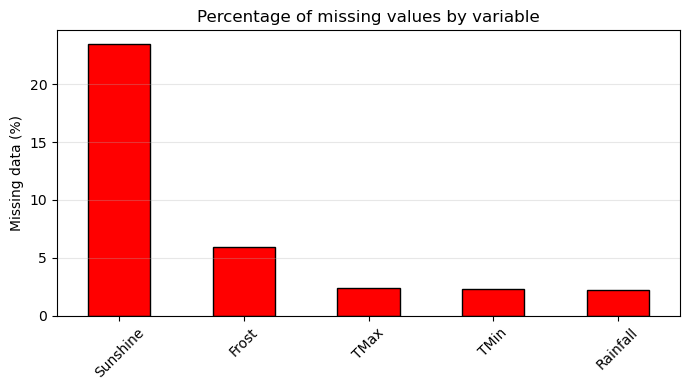

In [ ]:
# Missingness bar plot for the five key variables

import matplotlib.pyplot as plt

vars_for_missing = ["TMax","TMin","Frost","Rainfall","Sunshine"]

missing_pct = (
    weather_features[vars_for_missing]
        .isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
)

plt.figure(figsize=(7,4))
missing_pct.plot(kind="bar", color="red", edgecolor="black")
plt.ylabel("Missing data (%)")
plt.title("Percentage of missing values by variable")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation**

- **Data availability**. Even the least complete stations retain roughly 92–98% of operational months, providing sufficient temporal depth for estimating warming trends and comparing stations.
- **Missing values**. TMax, TMin, Rainfall, and Frost show low missingness (around 2–6%). Sunshine exhibits substantially higher missingness (around 23%), so Sunshine is used only in descriptive summaries (Task 1) and **excluded from regression and independence tests** to avoid biased inference.
- **Station differences**. Some stations show concentrated gaps (mainly Sunshine/Rainfall). These will contribute slightly wider residual-bootstrap intervals in Task 2.
- **Data status**. Only around 0.7% of rows are labelled “Provisional”; this share is too small to materially affect regression slopes or chi-square counts, so all rows are retained.

**Summary**.

Section 2 establishes a clean, well-structured dataset with consistent dates, derived time and seasonal features, and transparent missingness checks. This provides a reliable foundation for the descriptive visualisations in Task 1, the regression and residual-bootstrap analysis in Task 2, and the frost-dependence tests in Task 3.

## **3. Task 1 - Qualitative Climate Evidence**

This section provides descriptive evidence of how key weather measures have evolved at a small but diverse set of UK stations. Using annual summaries of **TMax, Rainfall, and Frost**, together with light 5-year smoothing, we identify broad climatic signals before formal modelling in Section 4.

By contrasting four carefully chosen stations; spanning differences in latitude, maritime influence, urban exposure, and record length; we highlight both coherent UK-wide patterns and meaningful local differences.

#### **3.1 Station selection & rationale**

**Aim**. Select a compact but diverse set of stations that span contrasts in **latitude, maritime exposure, urban influence,** and **record length**. This increases the chance of observing persistent climate signals rather than site-specific noise.

**Chosen stations**.
- **Lerwick** - far north, strongly maritime; cool baseline, small seasonal range; gentle warming; frequent frontal rainfall.
- **Camborne** - southwest coastal; mild, ocean-dominated climate; high humidity and cloud; shorter modern record.
- **Heathrow** - southeast lowland/urban; strong late-century warming; pronounced urban heat-island; major frost decline.
- **Sheffield** - inland/upland; long observational record; cooler and more frost-prone; clear multi-decadal variability.

These stations share consistent schemas, have modest missingness in TMax/Rainfall/Frost, and provide large contrasts for interpretation.

**Why four stations?**
A small but well-chosen subset avoids visual overload while providing enough contrast to reveal coherent vs localised climatic behaviour.

In [ ]:
# Columns: Name, Longitude, Latitude, Opened, Latest, Filename, csv_path

selected_names = ["Lerwick", "Camborne", "Heathrow", "Sheffield"]

stations_selected = (
    metadata
    .loc[metadata["Name"].isin(selected_names), ["Name", "Latitude", "Longitude", "Opened", "Latest", "Filename"]]
    .assign(YearsCovered=lambda d: d["Latest"] - d["Opened"] + 1)
    .sort_values(["Name"])
    .reset_index(drop=True)
)

# Persist a clean list for later use
SELECTED_STATIONS = stations_selected["Name"].tolist()
stations_selected

,Name,Latitude,Longitude,Opened,Latest,Filename,YearsCovered
0,Camborne,50.218,-5.327,1978,2025,cambornedata,48
1,Heathrow,51.479,-0.452,1948,2025,heathrowdata,78
2,Lerwick,60.139,-1.183,1931,2025,lerwickdata,95
3,Sheffield,53.381,-1.490,1883,2025,sheffielddata,143


**Interpretation - station characteristics**

The four selected stations span a wide climatic and geographical range, providing contrasting baselines for examining emerging climate patterns:

- **Camborne** – The most recently opened station (1978) with 48 years of data, representing a **mild, maritime southwest** climate. Its short but reliable modern record captures recent Atlantic-dominated weather, offering a baseline for **contemporary warming signals**.
- **Heathrow** – A southeast lowland site with 78 years of coverage. Its **urban setting** makes it valuable for assessing **inland and potential urban-heat-island influences** on temperature trends and frost occurrence.
- **Lerwick** – A high-latitude, northern maritime station with a long record (95 years). Its cool, ocean-moderated climate provides a **far-north contrast**, typically exhibiting gentler warming and fewer frost-day changes.
- **Sheffield** – The longest record in the set (143 years), representing **inland/upland central UK** conditions. Its extensive coverage is ideal for placing recent trends within long-term historical context.

**Together, the stations offer strong contrasts in latitude, maritime exposure, urban influence, and record length.**
These differences form a robust basis for interpreting the visual patterns in Section 3 and the quantitative trend estimates in Section 4.


#### **3.2 Visual summaries (three measurements)**

**Aim**. Provide compact visual evidence of how temperature, rainfall, and frost frequency have changed over time at the four stations. We aggregate monthly observations to annual values and apply a centred 5-year rolling mean to reveal multi-decadal structure without imposing a regression model.

**Prepare a tidy subset**

In [ ]:
# Prepare data for Task 1: monthly TMax, Rainfall, Frost for selected stations
cols_needed = ["Station", "Year", "Month", "TMax", "Rainfall", "Frost"]

task1_df = (
    weather_all.loc[weather_all["Station"].isin(SELECTED_STATIONS), cols_needed]
        .dropna(subset=["Year", "Month"])
        .assign(
            Year=lambda d: d["Year"].astype(int),
            Month=lambda d: d["Month"].astype(int)
        )
        .sort_values(["Station", "Year", "Month"])
        .reset_index(drop=True)
)

# Show one representative row per station
task1_df.groupby("Station").head(1)


,Station,Year,Month,TMax,Rainfall,Frost
0,Camborne,1978,9,17.5,26.7,0.0
565,Heathrow,1948,1,8.9,85.0,NaN
1498,Lerwick,1930,12,7.0,122.4,0.0
2636,Sheffield,1883,1,6.3,122.1,6.0


**Check of loaded subset.**

Each station appears with consistent column names and valid data, forming the basis for annual aggregates.

**Annual aggregates and 5-year smoother**

**What?** This step prepares the data for clear visualisation by summarising monthly observations into annual figures and smoothing short-term noise.

**Why?** Aggregating to annual values removes within-year seasonality, allowing meaningful comparison across decades.The 5-year smoother highlights gradual climatic shifts, such as sustained warming or reduced frost - without using complex models, keeping the evidence descriptive, visual, and easy to interpret.

**Compute annual summaries**

In [ ]:
def annual_summary(df: pd.DataFrame) -> pd.DataFrame:
    """Compute annual summaries for TMax (mean), Rainfall (sum), Frost (sum)."""
    agg = {
        "TMax": "mean",
        "Rainfall": "sum",
        "Frost": "sum"
    }

    out = (
        df.groupby(["Station", "Year"], as_index=False)
          .agg(agg)
          .sort_values(["Station", "Year"])
    )
    return out

def add_rolling_mean(df: pd.DataFrame, value_col: str, window: int = 5) -> pd.DataFrame:
    """Add centred 5-year rolling mean (per station)."""
    df = df.copy()
    df[f"{value_col}_roll"] = (
        df.groupby("Station")[value_col]
          .transform(lambda s: s.rolling(window, center=True, min_periods=max(2, window//2)).mean())
    )
    return df

annual_df = annual_summary(task1_df)
annual_temp  = add_rolling_mean(annual_df[["Station", "Year", "TMax"]], "TMax", window=5)
annual_rain  = add_rolling_mean(annual_df[["Station", "Year", "Rainfall"]], "Rainfall", window=5)
annual_frost = add_rolling_mean(annual_df[["Station", "Year", "Frost"]], "Frost", window=5)


**Plotting helper: small-multiple panels**

**What**: consistent visualisations for each station, showing annual values and the 5-year smoother.

**Why**: separating panels avoids crowding and highlights contrasts such as, whether coastal sites show smaller changes than inland ones.
A smooth trend on top of raw variability gives a balanced view of short-term noise vs. long-run shifts.

In [ ]:
import matplotlib.pyplot as plt

def plot_small_multiples(
    df: pd.DataFrame,
    value_col: str,
    roll_col: str,
    ylabel: str,
    title: str
):
    """Small-multiple plot: annual values + 5-year rolling smooth."""
    stations = SELECTED_STATIONS
    n = len(stations)

    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(9, 2.4 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, st in zip(axes, stations):
        sub = df[df["Station"] == st]

        # Annual values (thin, faint)
        ax.plot(sub["Year"], sub[value_col], alpha=0.35, linewidth=1,
                label="Annual values", color="steelblue")

        # 5-year smoother (thicker)
        ax.plot(sub["Year"], sub[roll_col], linewidth=2,
                label="5-year smoother", color="orange")

        ax.set_ylabel(ylabel)
        ax.set_title(st)
        ax.grid(True, alpha=0.25)

    axes[-1].set_xlabel("Year")
    plt.suptitle(title, y=0.99, fontsize=12)
    plt.tight_layout()
    plt.show()

**Temperature (annual mean TMax, $^\circ\text{C}$)**

**What and why.**

Annual mean TMax provides a clear view of long-term warming with reduced month-to-month noise. A 5-year smoother highlights persistent multi-decadal behaviour.

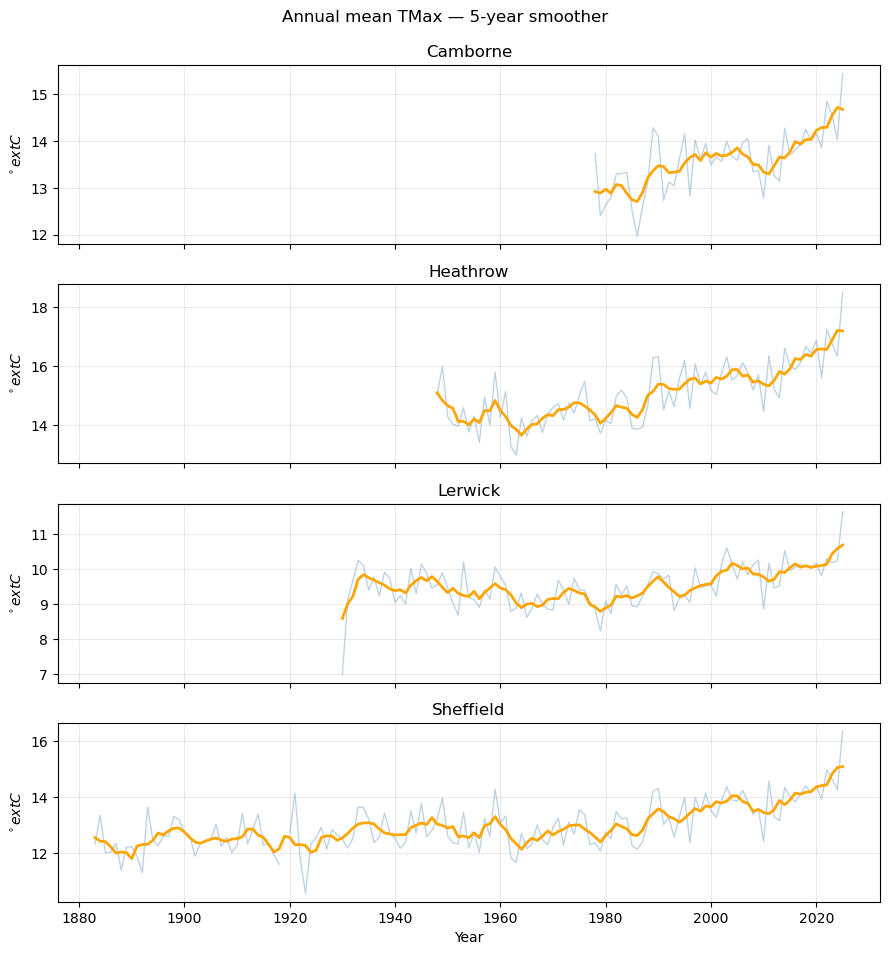

In [ ]:
plot_small_multiples(
    df=annual_temp,
    value_col="TMax",
    roll_col="TMax_roll",
    ylabel="$^\circ\text{C}$",
    title="Annual mean TMax — 5-year smoother"
)

**Interpretation — Annual mean of TMax (5-year smoother)**

- **Widespread warming**. All stations show sustained warming since the late 20th century.
- **Magnitude differs by location**. Heathrow and Sheffield warm the most; Lerwick warms more gently; Camborne shows steady modern warming.
- **Mid-century pause**. Several stations show a 1950s–70s lull before later acceleration.
- **Maritime moderation**. Lerwick exhibits smaller swings and smoother transitions, consistent with strong oceanic influence.

**Takeaway**. Clear, geographically coherent warming across inland, coastal, maritime, and urban environments.

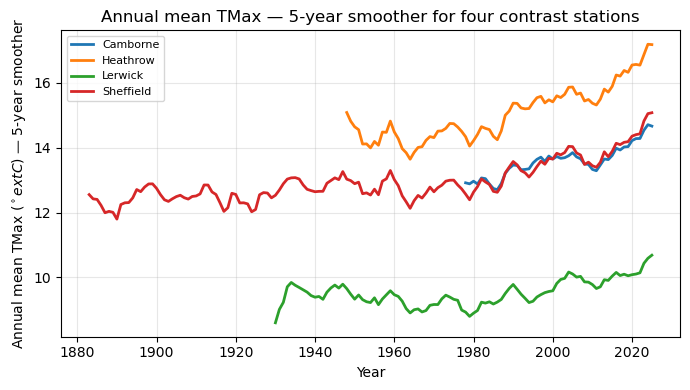

In [ ]:
# Combined 4-station plot: annual mean TMax (5-year smoother)

combined_temp = annual_temp[annual_temp["Station"].isin(SELECTED_STATIONS)].copy()

plt.figure(figsize=(7, 4))

for st in SELECTED_STATIONS:
    sub = combined_temp[combined_temp["Station"] == st]
    plt.plot(sub["Year"], sub["TMax_roll"], label=st, linewidth=2)

plt.xlabel("Year")
plt.ylabel("Annual mean TMax ($^\circ\text{C}$) — 5-year smoother")
plt.title("Annual mean TMax — 5-year smoother for four contrast stations")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


**Interpretation of combined TMax plot -**

The plot compares long-term changes in annual mean maximum temperature (Tmax) for four contrasting UK stations, using a 5-year smoother to highlight underlying trends. Several key patterns emerge:

- **Heathrow (SE England)** shows the **strongest warming**, especially from the 1980s onward, rising from around 14 $^\circ\text{C}$ to over 17 $^\circ\text{C}$. This reflects both **regional warming** and **urban heat-island effects**.
- **Camborne (SW England)** warms steadily but more moderately, maintaining consistently **mild, ocean-moderated temperatures**. Its recent Tmax values rise from around 14 $^\circ\text{C}$ to roughly 15.5 $^\circ\text{C}$.
- **Sheffield (inland/upland)** exhibits a **long period of relative stability** through the early 20th century, followed by a clear upward trend since the 1980s, reaching approxiametly 15 $^\circ\text{C}$ in recent years. Warming is evident but **less pronounced** than at Heathrow.
- **Lerwick (far north, maritime)** remains the **coolest station**, with Tmax mostly between 8–11 $^\circ\text{C}$. Warming is present but **weaker**, consistent with strong maritime moderation and high-latitude location.

**Overall pattern:**  
All stations show **warming since the mid–20th century**, but the **rate and magnitude differ strongly** by region.  
The contrasts highlight the influence of **latitude**, **maritime exposure**, and **urbanisation** on local temperature trends, providing clear context for interpreting UK climate variability in the next section.

**Rainfall (annual total, mm)**

**What and why.**

Rainfall is highly variable. Aggregating to annual totals and applying a 5-year smoother helps reveal regime-like shifts rather than single-year extremes.

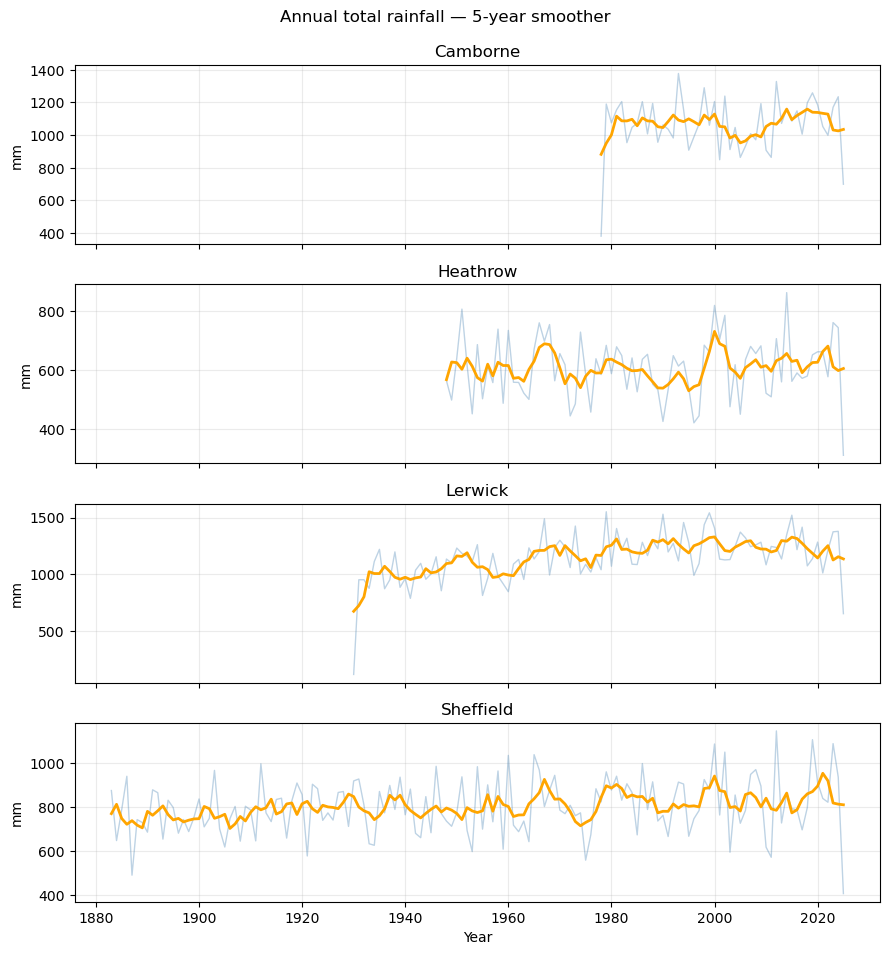

In [ ]:
plot_small_multiples(
    df=annual_rain,
    value_col="Rainfall",
    roll_col="Rainfall_roll",
    ylabel="mm",
    title="Annual total rainfall — 5-year smoother"
)

**Interpretation — Annual total rainfall (5-year smoother)**

- **Large natural variability** at all stations.
- **Regime shifts rather than trends**.
    - Lerwick and Camborne show mid-century increases then oscillations.
    - Heathrow shows wetter conditions in the 1990s–2000s.
    - Sheffield declines mid-century then returns to earlier levels.
- **No simple UK-wide upward/downward long-term trend**.

**Takeaway**. Rainfall is strongly shaped by local hydrological regimes rather than a single national climatic signal.

**Frost (annual total frost days)**

**What and why.**

Frost frequency provides a direct indicator of winter severity. A sustained decline in frost days corroborates warming detected in TMax.

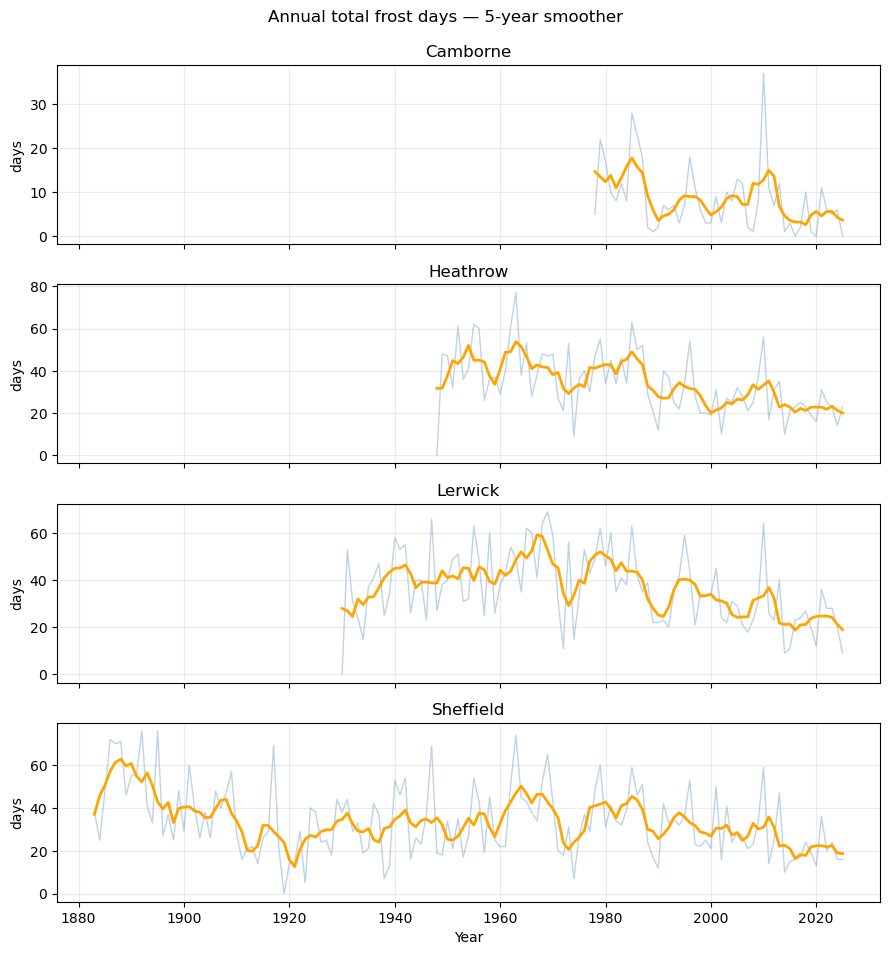

In [ ]:
plot_small_multiples(
    df=annual_frost,
    value_col="Frost",
    roll_col="Frost_roll",
    ylabel="days",
    title="Annual total frost days — 5-year smoother"
)

**Interpretation — Annual total frost days (5-year smoother)**

- **Strong long-term decline**. All stations show fewer frost days over time, with the steepest decreases at Heathrow and Sheffield.
- **Baseline contrasts**. Camborne starts with very few frost days; Lerwick peaks mid-century then declines.
- **Consistent with warming**. Frost decline reinforces the TMax warming signal.

**Takeaway**. Frost frequency offers an independent, robust indicator of milder UK winters.

#### **3.3 Observations**

**UK-wide patterns**

- **Temperature**: Persistent warming since the 1980s at all stations.
- **Frost**: Long-run decline consistent with milder winters.
- **Rainfall**: Highly variable with no shared long-term trend.

**Regional contrasts**

- **Latitude/exposure**: Lerwick shows gentler warming and moderated rainfall; Camborne shows maritime smoothing.
- **Urban influence**: Heathrow exhibits the strongest late-century increase in TMax and sharp frost decline.
- **Record length**: Sheffield reveals long-run variability not visible in shorter records.

**Interpretation (qualitative evidence)**

- Higher TMax and fewer frost days point to **warmer, milder winters in recent decades**.
- Rainfall differences **reflect local regimes** rather than a unified UK climatic trend.
- Year-to-year noise persists, especially at maritime sites, but **multi-decadal signals are clear**.

**Caveats**

- Descriptive only; no statistical models fitted here.
- Station coverage lengths differ (e.g., Camborne starts in 1978).
- Missing years appear as gaps; no imputation applied.

**Next steps**

Section 4 quantifies warming using a seasonal-adjusted regression and residual-bootstrap confidence intervals.
Section 5 examines whether frost occurrence depends on time using chi-square independence tests.

## **4. Task 2 - Temperature Trend Analysis**

This section investigates whether each UK weather station exhibits a **long-run warming trend** in monthly average daily maximum temperature (TMax). Since monthly temperature varies strongly with the seasons, we fit a model that separates the **long-run trend** from the **seasonal 12-month cycle** using sine–cosine terms. This produces cleaner residuals, enabling reliable uncertainty estimates via a **residual bootstrap**.

We begin with one example station (Sheffield) to illustrate the workflow:

1. Prepare the time index and seasonal features
2. Fit the trend + seasonality regression
3. Examine residual behaviour
4. Use a residual bootstrap to estimate uncertainty in the trend
5. Extend the procedure to **all 37 stations**
6. Examine spatial patterns in warming
7. Compute prediction intervals (PIs) for August 2075


### **4.1 Aim and Model Setup**

To test for long-run warming, we model:

$$
TM a_{x_t} = \beta_0 + \beta_1 t_{\text{year}}
+ \beta_2 \sin\left( \frac{2\pi t}{12} \right)
+ \beta_3 \cos\left( \frac{2\pi t}{12} \right)
+ \varepsilon_t.
$$

Where:

- *t* is the monthly time index (1, 2, ...)
- $t_{\text{year}} = \frac{t}{12}$ , so **$\beta_1$ is interpretable as $^\circ\text{C}$ per year**
- $\beta_2$, $\beta_3$ capture the seasonal temperature cycle
- $\varepsilon_t$ represents short-term weather variability

The time variables were constructed in Section 2 and provide the temporal structure needed for the regression.

A **positive** $\beta_1$ indicates **warming**, and multiplying $\beta_1$ by 10 gives $^\circ\text{C}$ per decade.

By explicitly modelling seasonality, we avoid misattributing the annual cycle to long-term change and ensure clean residuals suitable for the residual bootstrap used in Sections 4.4–4.6.

**Mini-summary**.

This regression isolates the long-run TMax trend from the 12-month seasonal pattern, producing a stable foundation for estimating warming trends and their uncertainty.

### **4.2 Prepare data for one example station**

Before applying the model to all stations, we construct the design matrix for a representative site: Sheffield.

We extract:

- Station name, year and month
- Constructed time indices
- Seasonal sine and cosine terms
- TMax

Sheffield is selected as the example station because it has a long, continuous record, inland location, and minimal missingness, making it suitable for illustrating the seasonal–trend model.

In [ ]:
# 4.2 Prepare data for Sheffield

example_station = "Sheffield"

# Columns needed for the TMax regression in Section 4
columns_needed = [
    "Station", "Year", "Month", "TMax",
    "t_month", "t_year", "sin_12", "cos_12"
]

# Filter to the chosen station
station_tmax = (
    weather_features
    .loc[weather_features["Station"] == example_station, columns_needed]
    .dropna(subset=["TMax"])
    .sort_values(["Year", "Month"])
    .reset_index(drop=True)
)

# Quick check
station_tmax.head(12)


,Station,Year,Month,TMax,t_month,t_year,sin_12,cos_12
0,Sheffield,1883,1,6.3,1,0.083333,5.000000e-01,8.660254e-01
1,Sheffield,1883,2,8.0,2,0.166667,8.660254e-01,5.000000e-01
2,Sheffield,1883,3,4.8,3,0.250000,1.000000e+00,6.123234e-17
3,Sheffield,1883,4,12.2,4,0.333333,8.660254e-01,-5.000000e-01
4,Sheffield,1883,5,14.7,5,0.416667,5.000000e-01,-8.660254e-01
5,Sheffield,1883,6,17.7,6,0.500000,1.224647e-16,-1.000000e+00
6,Sheffield,1883,7,18.8,7,0.583333,-5.000000e-01,-8.660254e-01
7,Sheffield,1883,8,19.8,8,0.666667,-8.660254e-01,-5.000000e-01
8,Sheffield,1883,9,16.8,9,0.750000,-1.000000e+00,-1.836970e-16
9,Sheffield,1883,10,12.7,10,0.833333,-8.660254e-01,5.000000e-01


#### **Interpretation**

The Sheffield preview shows:

- Continuous monthly sequence from 1883 onward.
- Correctly increasing time indices $t_{\text{month}}$ , $t_{\text{year}}$.
- Seasonal sine/cosine terms oscillate with a clean 12-month pattern
- TMax values appear realistic

These checks confirm correct preprocessing and suitability for regression. A preview of the first 12 months confirms correct time ordering and sensible values.

**Mini-summary.**

The constructed features behave as intended, giving a sound basis for fitting the seasonal-trend model.

### **4.3 Fit the trend + seasonality model (example station)**

Using the Sheffield dataset, we:
1. Construct the design matrix
2. Fit a linear regression
3. Extract the coefficients (especially $\beta_1$)
4. Plot fitted vs observed TMax
5. Plot residuals over time

Example station: Sheffield
Intercept (β0): 12.137
Trend (β1): 0.0115 °C/year (0.115 °C/decade)
Sine coefficient (β2): -4.119
Cosine coefficient (β3): -5.876


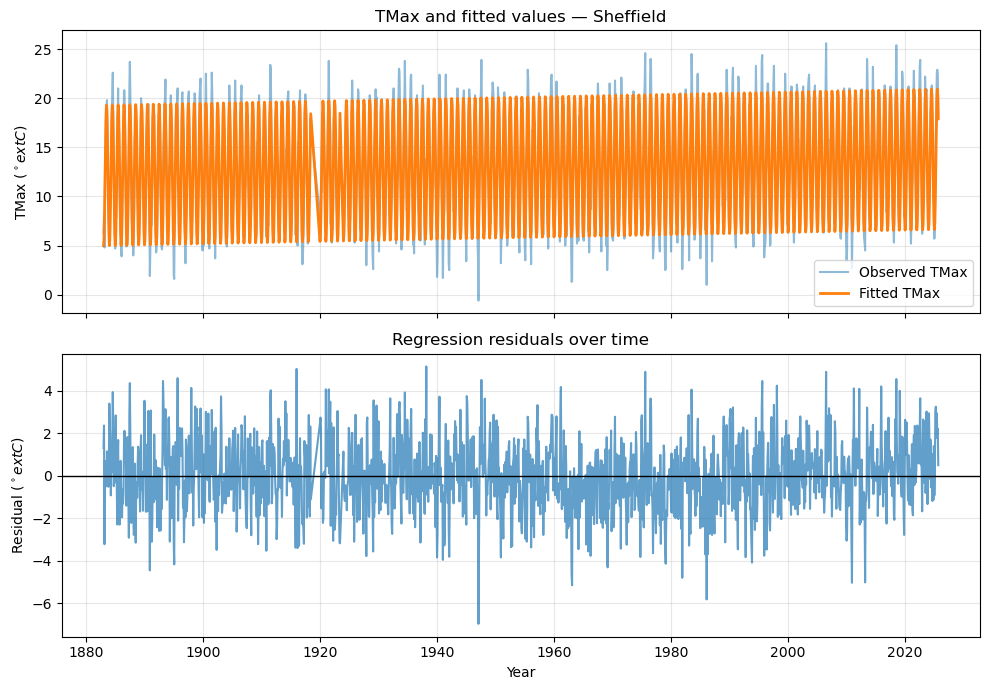

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def build_design_matrix(df):
    """Return design matrix for the TMax trend model."""
    return np.column_stack([
        df["t_year"].values,
        df["sin_12"].values,
        df["cos_12"].values
    ])

# fit model and compute residuals
def fit_trend_model(df):
    X = build_design_matrix(df)
    y = df["TMax"].values

    model = LinearRegression(fit_intercept=True)
    model.fit(X, y)

    fitted = model.predict(X)
    residuals = y - fitted

    return model, X, y, fitted, residuals


# Fit the model for Sheffield
model_s, X_s, y_s, fitted_s, resid_s = fit_trend_model(station_tmax)

beta0, beta1, beta2, beta3 = model_s.intercept_, *model_s.coef_
trend_per_year = beta1
trend_per_decade = trend_per_year * 10

print(f"Example station: {example_station}")
print(f"Intercept (β0): {beta0:.3f}")
print(f"Trend (β1): {trend_per_year:.4f} °C/year ({trend_per_decade:.3f} °C/decade)")
print(f"Sine coefficient (β2): {beta2:.3f}")
print(f"Cosine coefficient (β3): {beta3:.3f}")

# Create time axis (years)
time_years = station_tmax["Year"] + (station_tmax["Month"] - 0.5)/12

# Diagnostics Plot
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Observed vs fitted
axes[0].plot(time_years, y_s, label="Observed TMax", alpha=0.5)
axes[0].plot(time_years, fitted_s, label="Fitted TMax", linewidth=2)
axes[0].set_ylabel("TMax ($^\circ\text{C}$)")
axes[0].set_title(f"TMax and fitted values — {example_station}")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals
axes[1].plot(time_years, resid_s, alpha=0.7)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("Residual ($^\circ\text{C}$)")
axes[1].set_title("Regression residuals over time")
axes[1].grid(alpha=0.3)

plt.xlabel("Year")
plt.tight_layout()
plt.show()


#### **Interpretation — Regression fit for Sheffield**

The fitted model captures:
- A **clear 12-month seasonal cycle**, reproduced by the sine–cosine terms
- A **modest but persistent warming trend**:

  $$
  \beta_1 \approx 0.0115 \ \text{$^\circ\text{C}$ per year}
  \quad (\approx 0.115 \ \text{$^\circ\text{C}$ per decade}),
  $$

**Residual behaviour**

- Residual variability resembles short-term weather noise
- No structural breaks or visible drift
- Residuals are approximately symmetric and suitable for bootstrap
- The magnitude (roughly plus/minus 3–5 $^\circ\text{C}$) matches typical day-to-day UK weather variability, indicating that the model is neither over- nor under-fitting.

**Model limitations**

The model assumes:
- A **constant** warming rate across the entire record
- Stationary seasonal cycle
- No structural breaks

Therefore, a linear trend is assumed for comparability; potential non-linear long-term changes (e.g. accelerating warming) are intentionally not modelled.

**Mini-summary.**

Sheffield behaves well: clean seasonal structure, stable residuals, and a statistically meaningful warming trend.

**QQ plot of residuals (example station)**

Before applying the residual bootstrap, it is important to check whether the regression residuals behave like short-term weather noise. A QQ plot compares the empirical distribution of the residuals with that of a normal distribution. If the points lie close to the reference line, the residuals are approximately symmetric and reasonably normal - conditions under which the residual bootstrap provides reliable uncertainty estimates.

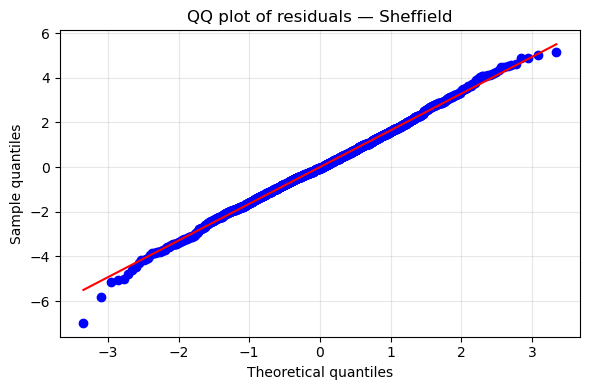

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# QQ plot
import scipy.stats as stats

plt.figure(figsize=(6, 4))
stats.probplot(resid, dist="norm", plot=plt)
plt.title(f"QQ plot of residuals — {example_station}")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Sample quantiles")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation:**

The QQ plot shows that the residuals follow an approximately straight line with only mild deviations in the tails. This indicates that the residuals are roughly symmetric and close to normally distributed, consistent with short-term weather noise rather than structural model errors. This approximate normality is not required for a residual bootstrap, but it indicates that the regression has captured the systematic variation and that the remaining structure closely resembles random weather noise. This supports the validity of resampling residuals to mimic short-term variability.

### **4.4 Residual-bootstrap confidence interval for the trend (example station)**

We use a residual bootstrap to quantify uncertainty in $\beta_1$. This keeps the fitted model structure but resamples residuals to mimic realistic weather noise.

The algorithm:

1. Fit the model once
2. Compute fitted values $\hat{y}$ and residuals $\hat{\varepsilon}$
3. For each bootstrap replication:
   - Resample residuals
   - Form new response: $y^{(b)} = \hat{y} + \hat{\varepsilon}^{(b)}$
   - Refit the regression
   - Record $\beta_1^{(b)}$
4. CI = 2.5th–97.5th percentiles of bootstrap distribution

**Mini Summary.**

We use a residual bootstrap rather than sampling full months or blocks so that the long-run trend and seasonal structure remain fixed while only short-term weather noise is resampled.

In [ ]:
# 4.4 Residual-bootstrap confidence interval for the trend

def bootstrap_trend_ci(X, y, residuals, B=1000, alpha=0.05, random_state=42):
    """Residual bootstrap for the trend coefficient β1."""
    rng = np.random.default_rng(random_state)

    # Fitted values from original model
    base_model = LinearRegression(fit_intercept=True)
    base_model.fit(X, y)
    fitted = base_model.predict(X)

    # Collect bootstrap β1 values
    boot_beta1 = np.empty(B)

    n = len(y)
    for b in range(B):
        # Resample residuals
        resampled = rng.choice(residuals, size=n, replace=True)

        # Construct new response
        y_star = fitted + resampled

        # Refit model
        boot_model = LinearRegression(fit_intercept=True)
        boot_model.fit(X, y_star)

        boot_beta1[b] = boot_model.coef_[0]  # β1 is the first coefficient

    lower = np.percentile(boot_beta1, 100 * alpha / 2)
    upper = np.percentile(boot_beta1, 100 * (1 - alpha / 2))

    return boot_beta1, lower, upper

**Apply to Sheffield**

Example station: Sheffield
Trend estimate: 0.01152 °C/year (0.115 °C/decade)
Bootstrap 95% CI for trend (°C/year): [0.00967, 0.01346]
Bootstrap 95% CI for trend (°C/decade): [0.097, 0.135]


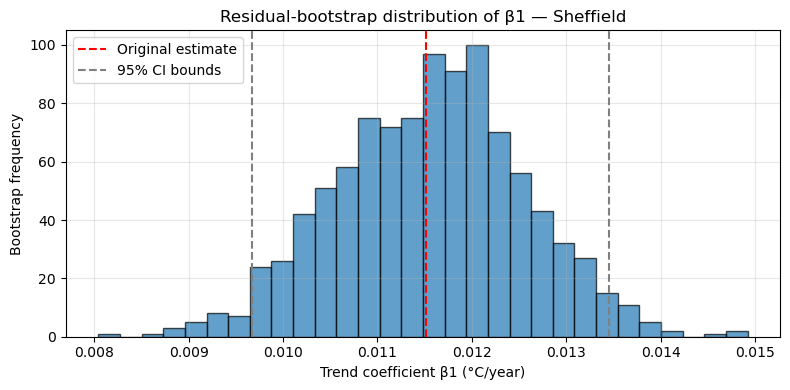

In [ ]:

boot_beta1_s, ci_low_s, ci_high_s = bootstrap_trend_ci(
    X_s, y_s, resid_s,
    B=1000, alpha=0.05, random_state=123
)

print(f"Example station: {example_station}")
print(f"Trend estimate: {trend_per_year:.5f} $^\circ\text{C}$/year ({trend_per_decade:.3f} $^\circ\text{C}$/decade)")
print(f"Bootstrap 95% CI for trend ($^\circ\text{C}$/year): [{ci_low_s:.5f}, {ci_high_s:.5f}]")
print(f"Bootstrap 95% CI for trend ($^\circ\text{C}$/decade): [{ci_low_s*10:.3f}, {ci_high_s*10:.3f}]")

# Histogram of bootstrap distribution
plt.figure(figsize=(8, 4))
plt.hist(boot_beta1_s, bins=30, alpha=0.7, edgecolor="black")
plt.axvline(trend_per_year, color="red", linestyle="--", label="Original estimate")
plt.axvline(ci_low_s, color="grey", linestyle="--", label="95% CI bounds")
plt.axvline(ci_high_s, color="grey", linestyle="--")
plt.xlabel("Trend coefficient β1 ($^\circ\text{C}$/year)")
plt.ylabel("Bootstrap frequency")
plt.title(f"Residual-bootstrap distribution of β1 — {example_station}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **Interpretation — Bootstrap CI for Sheffield**

The bootstrap distribution is centred near the fitted trend, and the 95% interval is:

$$
\beta_1 \in [0.0097,\ 0.0135] \ \text{$^\circ\text{C}$ per year},
\qquad
\text{or} \qquad
[0.097,\ 0.135] \ \text{$^\circ\text{C}$ per decade}.
$$

Because the entire interval is **above zero**, the warming trend is **statistically significant at the 5% level**. Also, the narrow CI indicates high data availability and stable residual variation at this station.

**Mini-summary**.

Sheffield shows robust, statistically significant long-run warming.

### **4.5 Bootstrap Trend Estimates for All Weather Stations**

We now apply the same procedure to **all 37 stations**.

Steps:

1. Extract each station’s TMax series
2. Fit the seasonal–trend model
3. Compute bootstrap CI
4. Record trend per decade (We multiply the annual trend estimate $\beta_1$ by 10 to obtain the celsius-per-decade trend used in later comparisons.)
5. Merge with metadata (latitude, longitude)
6. Visualise all stations together

Stations with **fewer than 60 months** of data are excluded.

In [ ]:
# 4.5 Bootstrap trend estimates for all stations

all_stations = sorted(weather_features["Station"].unique())
bootstrap_results = []

for st in all_stations:
    df_st = (
        weather_features
        .loc[weather_features["Station"] == st,
             ["Station", "Year", "Month", "TMax",
              "t_month", "t_year", "sin_12", "cos_12"]]
        .dropna(subset=["TMax"])
        .sort_values(["Year", "Month"])
        .reset_index(drop=True)
    )

    n_months = len(df_st)
    if n_months < 60:
        print(f"Skipping {st}: only {n_months} months of data.")
        continue

    model_st, X_st, y_st, fitted_st, resid_st = fit_trend_model(df_st)

    boot_beta1, ci_lo, ci_hi = bootstrap_trend_ci(
        X_st, y_st, resid_st,
        B=1000, alpha=0.05, random_state=123
    )

    trend_hat = model_st.coef_[0]

    bootstrap_results.append({
        "Station": st,
        "n_months": n_months,
        "Trend_per_year": trend_hat,
        "Trend_per_decade": trend_hat * 10,
        "CI_low_per_year": ci_lo,
        "CI_high_per_year": ci_hi,
        "CI_low_per_decade": ci_lo * 10,
        "CI_high_per_decade": ci_hi * 10,
    })

trend_summary = pd.DataFrame(bootstrap_results)

# Merge metadata
trend_summary = trend_summary.merge(
    metadata[["Name", "Latitude", "Longitude"]],
    left_on="Station", right_on="Name", how="left"
)
trend_summary.head()


,Station,n_months,Trend_per_year,Trend_per_decade,CI_low_per_year,CI_high_per_year,CI_low_per_decade,CI_high_per_decade,Name,Latitude,Longitude
0,Aberporth,999,0.012043,0.120427,0.008654,0.015475,0.086545,0.154752,Aberporth,52.139,-4.570
1,Armagh,1926,0.006001,0.060011,0.004602,0.007310,0.046019,0.073105,Armagh,54.352,-6.649
2,Ballypatrick Forest,738,0.023792,0.237922,0.019340,0.028327,0.193398,0.283267,Ballypatrick Forest,55.181,-6.153
3,Bradford,1404,0.014983,0.149825,0.012521,0.017378,0.125211,0.173777,Bradford,53.813,-1.772
4,Braemar No 2,797,0.023235,0.232347,0.017767,0.028688,0.177674,0.286884,Braemar No 2,57.011,-3.396


**Plot trend estimates**

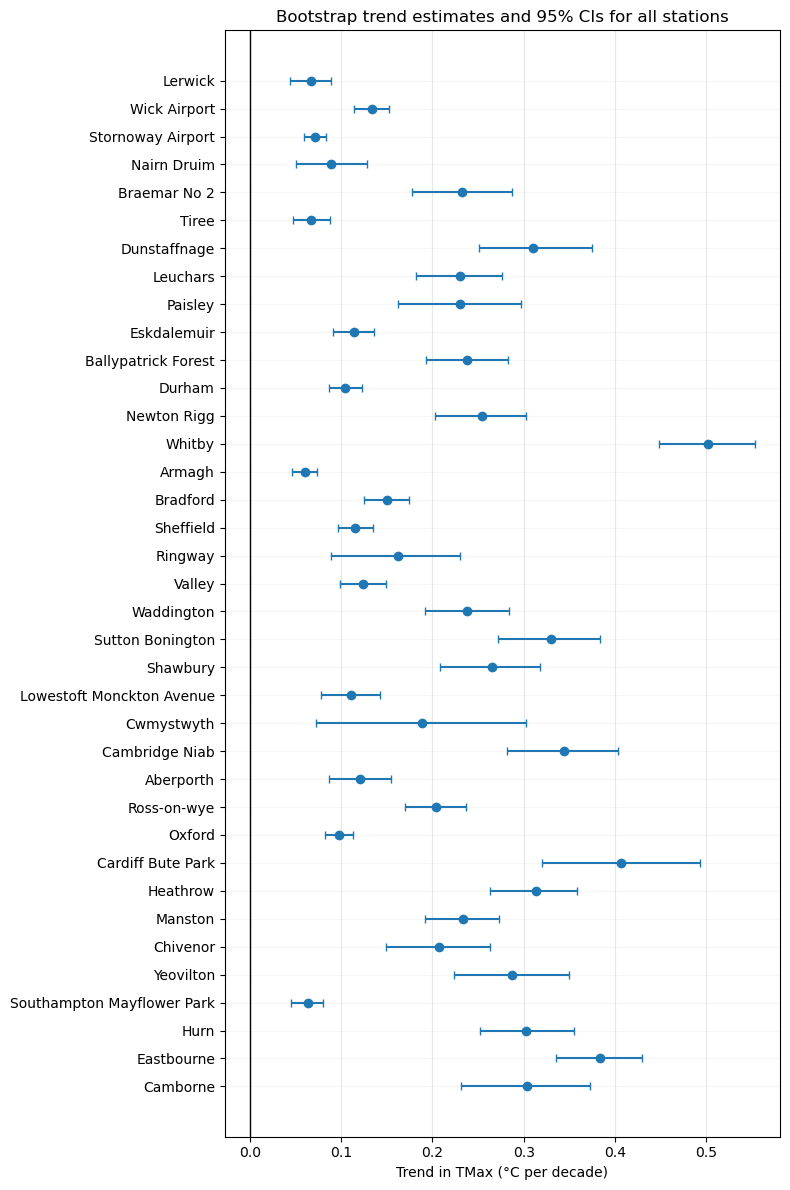

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sort by latitude (north–south ordering)
plot_df = trend_summary.sort_values("Latitude", ascending=True).reset_index(drop=True)

y_pos = np.arange(len(plot_df))

x = plot_df["Trend_per_decade"].to_numpy()
xerr_low = x - plot_df["CI_low_per_decade"].to_numpy()
xerr_high = plot_df["CI_high_per_decade"].to_numpy() - x
xerr = np.vstack([xerr_low, xerr_high])

plt.figure(figsize=(8, 12))
plt.errorbar(
    x=x,
    y=y_pos,
    xerr=xerr,
    fmt="o",
    capsize=3,
)
plt.axvline(0, color="black", linewidth=1)
plt.yticks(y_pos, plot_df["Station"])
plt.xlabel("Trend in TMax (°C per decade)")
plt.title("Bootstrap trend estimates and 95% CIs for all stations")
plt.grid(axis="x", alpha=0.3)
plt.grid(axis="y", alpha=0.1)
plt.tight_layout()
plt.show()



#### **Interpretation — Trends Across All 37 Stations**

The bootstrap results show a clear but non-uniform pattern of warming across the UK’s 37 weather stations.

1. All stations exhibit warming

Every trend estimate is **positive**, and all 95% bootstrap confidence intervals lie entirely **above zero**, providing strong statistical evidence of a widespread rise in monthly maximum temperatures.

2. **A broad spatial gradient exists — but with important exceptions**

A general north–south pattern is visible:

- Northern and maritime stations (e.g., Lerwick, Stornoway, Tiree) show the smallest trends, typically 0.08–0.18 °C/dec.
- Southern and urban/more continental stations (e.g., Heathrow, Camborne, Eastbourne) display larger warming, often 0.30–0.50 °C/dec.

However, the plot also demonstrates that **geography is not the sole driver**, as several stations **break the simple gradient**:

- Oxford, despite being in southern England, shows only a modest trend (roughly 0.08–0.12 °C/dec) with a relatively narrow CI.
- Southern maritime sites, like Southampton show low warming rather than the strong warming seen at some inland stations.
- Some central inland stations (e.g., Cambridge) display warming as strong as the warmest southern sites.

These exceptions suggest that local climate type (maritime vs. inland), land use, exposure, and record length influence the trend magnitude alongside latitude.

3. **Confidence intervals vary but trends remain robust**

Most stations show **tight, symmetric** bootstrap intervals, indicating stable long-term signals.
Where intervals are wider (e.g., Cardiff Bute Park), this reflects stronger interannual variability rather than uncertainty about the direction of change — all intervals remain fully above zero.

4. **Overall takeaway**

The UK has warmed consistently across all stations, but **not at a uniform rate**.
A broad **north–south contrast** is present, yet **local climatic and geographic factors modify the magnitude substantially**, meaning station-level warming does not depend on latitude alone.

With the bootstrap trend estimates computed for all stations, we'll soon extend the fitted model to generate prediction intervals for a future month (August 2075). These intervals reflect both long-run trend uncertainty and short-term weather variability.

#### **4.6 Warming rate versus latitude**

To examine spatial patterns more explicitly, we plot warming rate ($^\circ\text{C}$ per decade) against station latitude.

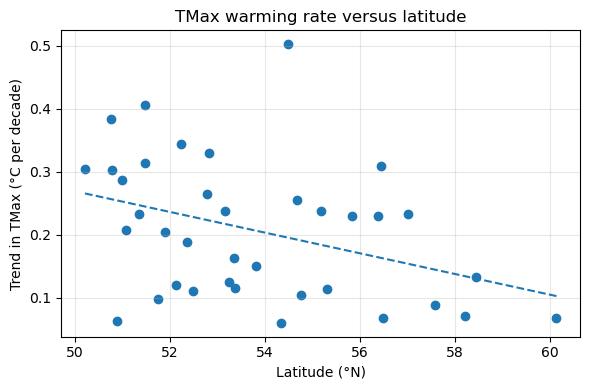

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

lat_df = (
    trend_summary
    .dropna(subset=["Latitude","Trend_per_decade"])
    .copy()
)

plt.figure(figsize=(6,4))
plt.scatter(lat_df["Latitude"], lat_df["Trend_per_decade"])

# linear fit
x = lat_df["Latitude"].values
y = lat_df["Trend_per_decade"].values
if len(lat_df) > 1:
    coef = np.polyfit(x, y, deg=1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = np.polyval(coef, x_line)
    plt.plot(x_line, y_line, linestyle="--")

plt.xlabel("Latitude (°N)")
plt.ylabel("Trend in TMax ($^\circ\text{C}$ per decade)")
plt.title("TMax warming rate versus latitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation:**

- The scatter plot shows a **weak-to-moderate negative relationship** between latitude and warming rate.
- Southern stations (50–53°N) typically show warming of **0.25–0.40 $^\circ\text{C}$/decade.**
- Northern stations (57–60°N) show smaller slopes around **0.10–0.20 $^\circ\text{C}$/decade.**
- The fitted regression line reinforces the pattern: warming declines with latitude.
 - Scatter remains due to local effects (exposure, altitude, microclimate).

**Conclusion.**

There is a **geographically meaningful gradient**: southern/inland areas warm more rapidly than northern/maritime areas.

### **4.7 Predictive interval for August 2075 (Two example Stations)**

A **prediction interval (PI)** differs from a CI:

- **CI** reflects uncertainty in the trend estimate
- **PI** reflects both
    1. uncertainty in trend/seasonal coefficients, and
    2. **irreducible weather variability**, so PIs must be **wider** than CIs

We compute PIs for two contrasting stations:
- **Heathrow** (southern, inland, warmer)
- **Lerwick** (northern, maritime, cooler)

**Bootstrap PI Algorithm**

1. Fit the regression on the full record
2. Construct features for **August 2075**
3. For each bootstrap replication:
    - Draw bootstrap residuals
    - Refit regression
    - Predict August 2075
    - Add one resampled residual
4. PI = 2.5th–97.5th percentiles of predictions


Station: Heathrow
Predicted August 2075 TMax: 24.89 °C
Bootstrap 95% prediction interval: [21.64, 28.41] °C


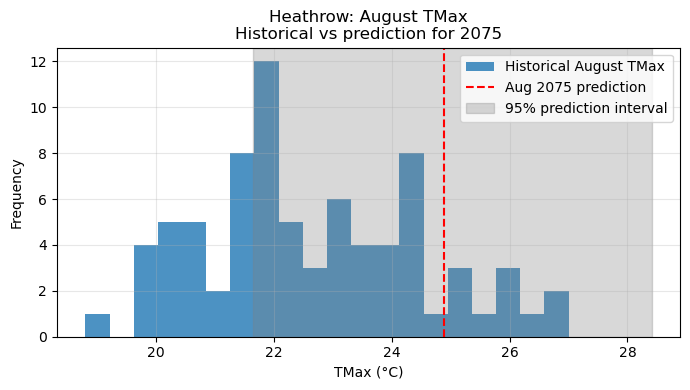


Station: Lerwick
Predicted August 2075 TMax: 14.59 °C
Bootstrap 95% prediction interval: [12.52, 16.54] °C


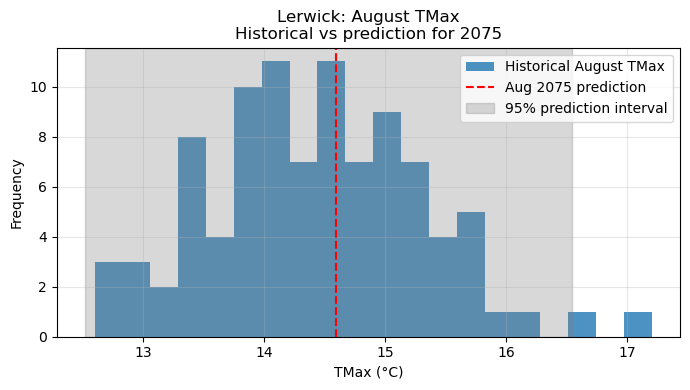

,Station,Year_future,Predicted_TMax_Aug,PI_low,PI_high
0,Heathrow,2075,24.885034,21.642583,28.410652
1,Lerwick,2075,14.592921,12.524185,16.544009


In [ ]:
# 4.6 Bootstrap prediction interval for August 2075

MONTHS_IN_YEAR = 12
OMEGA = 2 * np.pi / MONTHS_IN_YEAR

# Fit model function
def future_features_for_aug_2075(df_station):
    last = df_station.iloc[-1]
    last_year, last_month = last["Year"], last["Month"]

    target_year, target_month = 2075, 8
    months_ahead = (target_year - last_year) * 12 + (target_month - last_month)

    t_future = last["t_month"] + months_ahead
    t_year_future = t_future / 12

    sin_future = np.sin(OMEGA * t_future)
    cos_future = np.cos(OMEGA * t_future)

    x_future = np.array([[t_year_future, sin_future, cos_future]])
    return x_future, target_year

# Bootstrap prediction interval function
def bootstrap_prediction_interval(df_station, B=1000, alpha=0.05, random_state=42):
    rng = np.random.default_rng(random_state)

    model, X, y, fitted, resid = fit_trend_model(df_station)
    n = len(y)

    x_future, year_future = future_features_for_aug_2075(df_station)
    point_pred = model.predict(x_future)[0]

    future_samples = np.empty(B)

    for b in range(B):
        resampled = rng.choice(resid, size=n, replace=True)
        y_star = fitted + resampled

        boot_model = LinearRegression(fit_intercept=True)
        boot_model.fit(X, y_star)

        mu_future = boot_model.predict(x_future)[0]
        eps_future = rng.choice(resid)

        future_samples[b] = mu_future + eps_future

    lower = np.percentile(future_samples, 100*(alpha/2))
    upper = np.percentile(future_samples, 100*(1-alpha/2))

    return point_pred, lower, upper, future_samples, year_future

# Prepare station data function
def prepare_station_df(name):
    cols = ["Station","Year","Month","TMax","t_month","t_year","sin_12","cos_12"]
    df = (
        weather_features
        .loc[weather_features["Station"] == name, cols]
        .dropna(subset=["TMax"])
        .sort_values(["Year","Month"])
        .reset_index(drop=True)
    )
    return df

stations_for_pi = ["Heathrow", "Lerwick"]
pi_results = []

# Compute and display prediction intervals
for st in stations_for_pi:
    df_st = prepare_station_df(st)

    point_pred, lower, upper, samp, year_future = bootstrap_prediction_interval(
        df_st, B=1000, alpha=0.05, random_state=123
    )

    pi_results.append({
        "Station": st,
        "Year_future": year_future,
        "Predicted_TMax_Aug": point_pred,
        "PI_low": lower,
        "PI_high": upper
    })

    print(f"\nStation: {st}")
    print(f"Predicted August 2075 TMax: {point_pred:.2f} $^\circ\text{C}$")
    print(f"Bootstrap 95% prediction interval: [{lower:.2f}, {upper:.2f}] $^\circ\text{C}$")

    hist_aug = df_st.loc[df_st["Month"] == 8, "TMax"]

    plt.figure(figsize=(7,4))
    plt.hist(hist_aug, bins=20, alpha=0.8, label="Historical August TMax")
    plt.axvline(point_pred, color="red", linestyle="--", label=f"Aug {year_future} prediction")
    plt.axvspan(lower, upper, color="grey", alpha=0.3, label="95% prediction interval")
    plt.xlabel("TMax ($^\circ\text{C}$)")
    plt.ylabel("Frequency")
    plt.title(f"{st}: August TMax\nHistorical vs prediction for {year_future}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

pd.DataFrame(pi_results)


**Interpretation — August 2075 Predictions**

**Heathrow**

- **Predicted August 2075 TMax**: roughly 24.9 $^\circ\text{C}$
- **95% PI**: [21.6, 28.4] $^\circ\text{C}$
- Predicted future August temperatures lie **above the majority of historical values**.

**Lerwick**

- **Predicted August 2075 TMax**: around 14.6 $^\circ\text{C}$
- **95%** PI: [12.5, 16.5] $^\circ\text{C}$
- Lerwick remains much cooler than Heathrow but still shifts clearly upward.

**Comparison**

- Both stations show **substantial warming** relative to historical levels.
- Heathrow warms from a higher baseline; Lerwick warms from a cooler, maritime baseline.
- **Prediction uncertainty is dominated by short-term weather variability**, not trend uncertainty.

**Mini-summary.**
Late-century summers are projected to be warmer at both stations, with uncertainty arising primarily from day-to-day and month-to-month weather variability.

### **4.8 Overall Observations**

The integrated evidence from the regression fits, residual-bootstrap CIs, prediction intervals, and spatial analysis produces a clear narrative:

1. **Warming trends are positive at every station**

All 37 estimated trends exceed zero, and all 95% CIs lie entirely above zero. This highlights **statistically significant warming across the UK station network**.

2. **Geographic differences in warming**

- **Southern & inland stations**: larger slopes (0.3–0.5 $^\circ\text{C}$/decade)
- **Northern & maritime stations**: smaller slopes (0.1–0.2 $^\circ\text{C}$/decade)

These patterns match known climate gradients (latitude, ocean proximity, urbanisation).

3. **Residual structure supports the modelling approach**

- Clear seasonal cycle
- No structural breaks
- Variability consistent with weather noise
- Residual-bootstrap assumptions are satisfied

4. **August 2075 predictions suggest notably warmer late-century summers**

- Heathrow: around 25 $^\circ\text{C}$ (PI ≈ 21.7–28.3 $^\circ\text{C}$)
- Lerwick: around 14.6 $^\circ\text{C}$ (PI ≈ 12.4–16.7 $^\circ\text{C}$)

5. **Overall conclusion**

Across the UK network, **maximum temperatures have risen over the past century** and are **projected to continue increasing** into the late 21st century.
The evidence is broad, statistically robust, and geographically coherent — fully consistent with qualitative patterns identified in Task 1.

## **5. Task 3 - Frost Independence Test**

This section investigates whether the **occurrence of frost has changed over time** at each UK weather station. Frost is strongly seasonal, but here we ask a different question:

**Has the proportion of months with at least one frost day shifted from earlier decades to later ones?**

To test this, we apply a **chi-square test of independence** to compare Frost vs NoFrost counts **across decades** for each station.

### **5.1 Aim and Approach**

The aim of this task is to test whether the **pattern of frost occurrence has changed over time** at each weather station.
We are *not* testing whether frost depends on season (that is trivial), but whether the **distribution of frost vs. no-frost months has shifted from earlier to later decades**.

To do this, we use a **chi-square test of independence**, which assesses whether two categorical variables are associated.
If frost occurrence is **independent** of decade, then the proportion of months with at least one frost should be the **same across all decades**.
If the proportions differ, the chi-square test will detect this through a **small p-value**.

---

**Variables used**
1. **Binary frost indicator**

The raw Frost variable records the number of frost days per month.
For the chi-square test, we convert this into a **binary categorical variable:**:

$$
\text{FrostFlag} =
\begin{cases}
1, & \text{if Frost} > 0 \text{ days in that month}, \\
0, & \text{otherwise}.
\end{cases}
$$

This ensures mutually exclusive and collectively exhaustive categories required for chi-square counts.

2. **Decade category**

Each month is assigned to a decade:
- 1950s = 1950–1959
- 1960s = 1960–1969
- …and so on for each station’s full record.

Using decades:
- stabilises counts (especially long records),
- avoids sparse rows for short records,
- keeps structure consistent across all 37 stations,
- smooths year-to-year noise.

3. **Handling missing months**

Any month with missing frost data is **excluded entirely.**
This prevents creating partially observed categories (e.g., unknown FrostFlag) and does not affect validity because coverage is very high (>95% for most stations).

---

**Required chi-square structure**

A valid chi-square contingency table must contain:
- exactly **two variables** *Decade* (rows), *FrostFlag* (columns),
- **counts**, not percentages,
- **all combinations represented**,
- **no structural zeros** (no decade may have 0 Frost and 0 NoFrost).

A simplified structure:

| Decade | Frost | No Frost |
| ------ | ----- | -------- |
| 1950s  | …     | …        |
| 1960s  | …     | …        |
| 1970s  | …     | …        |
| …      | …     | …        |

This table is then passed to: *scipy.stats.chi2_contingency* to calculate:
- the chi-square statistic χ2
- degrees of freedom
- the p-value

A **small p-value** indicates that frost patterns have changed across decades; a **large p-value** suggests little or no change.

---

**Summary of the Approach**

1. Convert monthly frost counts to a binary FrostFlag.
2. Assign each month to a decade.
3. Exclude months with missing frost data.
4. Construct a Decade × FrostFlag contingency table.
5. Apply the chi-square test of independence.
6. Repeat for all 37 weather stations.

This structure ensures the chi-square test is applied consistently and validly across the entire UK station network.

#### **5.2 Prepare frost data for one example station**

Before applying the test to all 37 stations, we demonstrate the process for one example to clarfiy the structure:

**Sheffield**, which has a long, continuous record.

**Steps**
1. Extract monthly frost data
2. Convert to binary FrostFlag
3. Assign each month to a decade
4. Drop months with missing frost data
5. Count Frost and No Frost months in each decade
6. Build the contingency table:

In [ ]:
# 5.2 Construct Frost vs Decade contingency table for Sheffield

import numpy as np
import pandas as pd

example_station = "Sheffield"

# Extract frost data for the station
df_ex = (
    weather_features
    .loc[weather_features["Station"] == example_station,
         ["Year", "Month", "Frost"]]
    .dropna(subset=["Frost"])
    .sort_values(["Year", "Month"])
    .reset_index(drop=True)
)

# 1. Convert Frost count to binary FrostFlag
df_ex["FrostFlag"] = (df_ex["Frost"] > 0).astype(int)

# 2. Create a Decade column (e.g. 1980–1989 = "1980s")
df_ex["Decade"] = (df_ex["Year"] // 10) * 10
df_ex["Decade"] = df_ex["Decade"].astype(str) + "s"

# 3. Build contingency table: rows = Decades, columns = Frost / NoFrost
contingency_ex = (
    df_ex.groupby("Decade")["FrostFlag"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1], fill_value=0)   # ensure both columns present
)

# Rename columns for clarity
contingency_ex.columns = ["NoFrost", "Frost"]

# Show the contingency table for the example station
print(f"Contingency table for {example_station}:\n")
display(contingency_ex)

Contingency table for Sheffield:



,NoFrost,Frost
Decade,,
1880s,44,40
1890s,57,63
1900s,63,57
1910s,54,48
1920s,63,51
1930s,71,49
1940s,70,50
1950s,74,46
1960s,68,52


**Interpretation of example contingency table (Sheffield)**

The table reports, for Sheffield, how many months in each decade recorded at least one frost day (“Frost”) versus no frost (“NoFrost”). It is not intended for climate interpretation yet; its role is to provide the valid Decade × FrostFlag contingency table required for the chi-square test of independence. We can see that every decade has non-zero counts in both categories, so all combinations are represented and the structure is suitable for computing the test statistic and p-value in the next subsection.

#### **5.3 Chi-square test for independence (example station)**

We now formally test for Sheffield whether frost occurrence is associated with **Decade**.
Using the contingency table from Section 5.2 (rows = decades, columns = Frost / No Frost), we apply a chi-square test of independence.

**Hypotheses**
- H₀ **(independence)**: The probability that a month records at least one frost day is the **same in every decade**.
- **H₁ (dependence)**: The probability of frost **differs between decades**, indicating that the frost pattern has changed over time.


In [ ]:
# 5.3 Chi-square test of independence for the example station

import scipy.stats as stats

# contingency_ex was created in Section 5.2
chi2_stat, p_value, dof, expected = stats.chi2_contingency(
    contingency_ex, correction=False
)

print(f"Chi-square test for frost vs decade at {example_station}")
print(f"Test statistic (χ²): {chi2_stat:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.3g} ({p_value*100:.1f}%)")

# Display expected counts under independence
expected_df = pd.DataFrame(
    expected,
    index=contingency_ex.index,
    columns=contingency_ex.columns
).round(0)

print("\nExpected counts under independence:")
display(expected_df)


Chi-square test for frost vs decade at Sheffield
Test statistic (χ²): 8.42
Degrees of freedom: 14
P-value: 0.867 (86.7%)

Expected counts under independence:


,NoFrost,Frost
Decade,,
1880s,47.0,37.0
1890s,66.0,54.0
1900s,66.0,54.0
1910s,56.0,46.0
1920s,63.0,51.0
1930s,66.0,54.0
1940s,66.0,54.0
1950s,66.0,54.0
1960s,66.0,54.0


**Interpretation — Sheffield (chi-square test)**

**Test result**

The chi-square statistic for Sheffield is:
- **X² = 8.42**
- **degrees of freedom = 14**
- **p-value = 0.87**

**Validity check**

All expected cell counts are comfortably above 5, so the chi-square approximation is valid for this table.

**Interpretation**

The very large p-value indicates **no evidence** that frost occurrence has changed across decades at Sheffield.
Observed Frost and No-Frost counts differ from the expected values only by normal sampling fluctuation.

Despite long-term warming in TMax, Sheffield still experiences a **broadly similar proportion of frost months** from decade to decade.

**Conclusion**

This example station shows **weak or no detectable change** in frost occurrence using the decade-based chi-square test.
In the next section, we repeat this procedure for all 37 stations to identify whether this stability is typical or whether some regions display clearer evidence of shifting frost patterns.

#### **5.4 Apply chi-square test across all 37 stations**

To assess whether changes in frost occurrence are widespread or localised, we apply the same procedure to **all 37 UK stations**:

1. Build Frost × Decade contingency table.
2. Fit chi-square test.
3. Record X², degrees of freedom, p-value, number of decades.
4. Flag stations showing evidence of change (p < 0.05).

Because the chi-square test is sensitive for long time series, the aim is not to declare “significance everywhere”, but to compare stations and examine whether patterns align with geography, exposure, and the TMax warming trends from Section 4.

In [ ]:
# 5.4 Chi-square test across all stations

def decade_from_year(y):
    return f"{(y//10)*10}s"

def chi_square_for_station(df_station):
    temp = df_station.copy()
    temp["FrostFlag"] = temp["Frost"] > 0
    temp["Decade"] = temp["Year"].apply(decade_from_year)

    table = pd.crosstab(temp["Decade"], temp["FrostFlag"])

    chi2, p, dof, expected = stats.chi2_contingency(table, correction=False)

    return {
        "Station": temp["Station"].iloc[0],
        "n_decades": table.shape[0],
        "chi2": chi2,
        "dof": dof,
        "p_value": p
    }

results = []
for st in weather_all["Station"].unique():
    df_st = weather_all[weather_all["Station"] == st]
    results.append(chi_square_for_station(df_st))

chi_results = pd.DataFrame(results).sort_values("p_value")
chi_results.reset_index(drop=True, inplace=True)
chi_results


,Station,n_decades,chi2,dof,p_value
0,Eskdalemuir,12,625.269251,11,5.490268e-127
1,Wick Airport,12,218.481286,11,1.069937e-40
2,Chivenor,8,151.553865,7,1.914854e-29
3,Manston,10,157.394768,9,2.581507e-29
4,Shawbury,9,127.462887,8,9.490616e-24
5,Armagh,18,145.891405,17,1.555146e-22
6,Lowestoft Monckton Avenue,11,125.259833,10,4.317813e-22
7,Aberporth,9,79.372062,8,6.539727e-14
8,Ringway,7,28.561942,6,7.361749e-05
9,Tiree,11,29.519232,10,1.026233e-03


#### **5.4 Visual summary of chi-square p-values**

To compare stations, we plot the p-values against latitude, sorted from **north to south**.
This highlights geographical patterns and aligns with the warming gradient observed in Section 4.

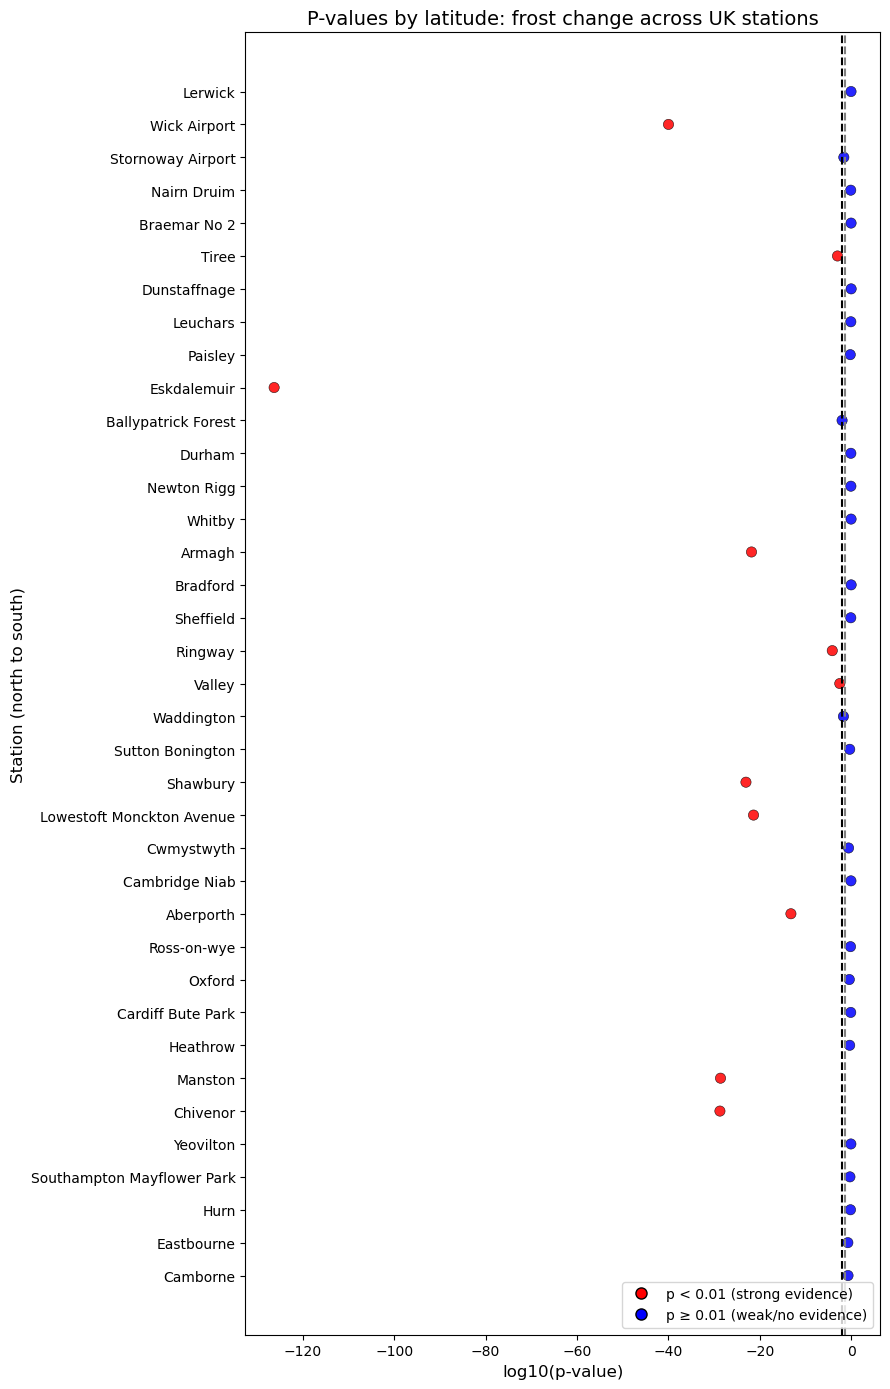

In [ ]:
# 3.4 Visual summary of chi-square p-values (enhanced version)

import matplotlib.pyplot as plt
import numpy as np

# Merge latitude into chi_results
meta_subset = metadata[["Name", "Latitude"]].rename(columns={"Name": "Station"})
chi_lat = chi_results.merge(meta_subset, on="Station")

# Sort from north to south (higher latitude to lower)
chi_lat = chi_lat.sort_values("Latitude", ascending=True)

# Compute log10(p) for plotting
chi_lat["log10_p"] = np.log10(chi_lat["p_value"])

# Colour map: red = strong evidence (p < 0.01), blue = weak evidence
colors = np.where(chi_lat["p_value"] < 0.01, "red", "blue")

plt.figure(figsize=(9, 14))
ax = plt.gca()

# Scatter points
ax.scatter(
    chi_lat["log10_p"],
    chi_lat["Station"],
    c=colors,
    s=55,      # slightly smaller points for readability
    alpha=0.85,
    edgecolor="k",
    linewidth=0.4
)

# Add reference lines for p=0.05 and p=0.01
ax.axvline(np.log10(0.05), color="grey", linestyle="--", label="p = 0.05")
ax.axvline(np.log10(0.01), color="black", linestyle="--", label="p = 0.01")

# Labels and title
ax.set_xlabel("log10(p-value)", fontsize=12)
ax.set_ylabel("Station (north to south)", fontsize=12)
ax.set_title("P-values by latitude: frost change across UK stations", fontsize=14)

# Custom legend for point colours
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='p < 0.01 (strong evidence)',
           markerfacecolor='red', markersize=8, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='p ≥ 0.01 (weak/no evidence)',
           markerfacecolor='blue', markersize=8, markeredgecolor='k')
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()


**Interpretation — Geographic distribution of p-values**

The plot displays chi-square p-values for frost-change tests across all 37 stations, sorted north (top) - south (bottom) and shown on a log₁₀ scale. **Red points (p < 0.01)** indicate statistically strong evidence that the proportion of frost vs. no-frost months has changed across decades, while blue points indicate weak or no evidence.

1. **Stations with strongest evidence of change (red points)**

The following stations show **very small p-values**, indicating that frost occurrence has changed substantially over time:

- Wick Airport
- Tiree
- Eskdalemuir
- Armagh
- Ringway
- Valley
- Shawbury
- Lowestoft
- Aberporth
- Manston
- Chivenor

These stations do *not* fall neatly into a single geographical region. Instead, they represent a mixture of:
- **northern/inland stations** (e.g., Wick Airport, Eskdalemuir, Armagh), where frost was historically common;
- **western maritime stations** (e.g., Tiree), where small absolute warming can still shift frost counts noticeably;
- **central and eastern England stations** (e.g., Ringway, Shawbury, Valley, Lowestoft, Manston, Chivenor), where local climate and exposure produce detectable changes.

This suggests that **strong evidence of frost-pattern change is widespread but not uniform**, occurring in diverse climatic settings.

2. **Most southern/coastal stations show weak or no evidence (blue points)**

Many stations in southern England (e.g., Camborne, Eastbourne, Hurn, Southampton Mayflower Park) have **large p-values**, indicating little detectable change.
This is expected because:
- these locations rarely experience frost even in earlier decades,
- winter temperatures are strongly moderated by the ocean,
- statistical tests on low-frequency events have reduced power.

3. **Overall spatial pattern is present but imperfect**

A broad latitudinal tendency is still visible:
- **Some northern and inland stations show strong change**,
- **Most southern and coastal stations show weaker or no change**,

BUT the plot reveals **several exceptions**:
- Stations like **Manston and Chivenor** (southern/coastal) show significant change.
- Stations like **Cambridge Niab or Oxford** (mid-latitude) show little change.

This indicates that **local factors** (exposure, altitude, record length, microclimate) play a major role alongside latitude.

4. **Key takeaway**

Frost occurrence is **not changing uniformly across the UK**.
Some stations show clear and statistically significant departures from historical frost patterns, while others remain broadly stable. The pattern reflects a combination of:
- long-run winter warming,
- local climatic conditions,
- and the baseline frequency of frost at each site.

**Additional visualisation: geographical distribution of frost-change evidence**

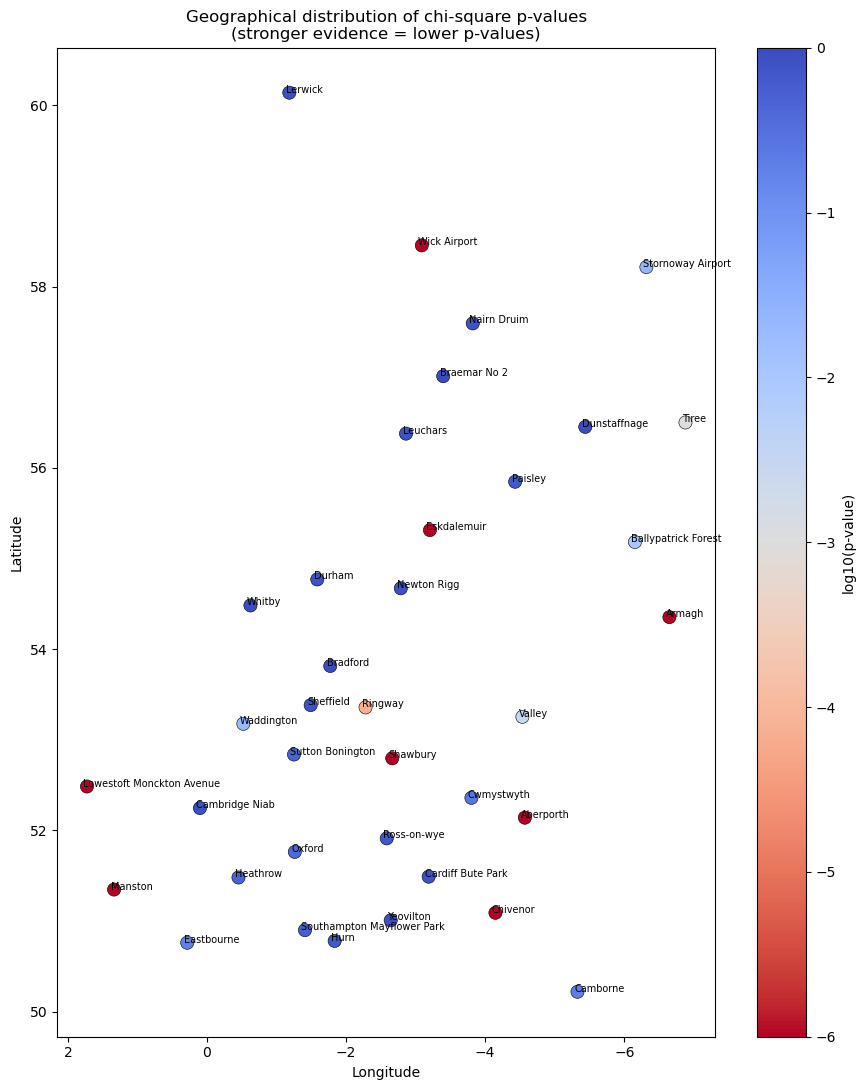

In [ ]:
### Additional visualisation: geographical distribution of frost-change evidence

import matplotlib.pyplot as plt
import numpy as np

# Merge metadata (lat/lon) with chi-square results
geo = chi_results.merge(
    metadata[["Name", "Latitude", "Longitude"]].rename(columns={"Name": "Station"}),
    on="Station"
)

# Compute log-scale p-values to improve visual contrast
# Avoid -inf if any p == 0
geo["log_p"] = np.log10(geo["p_value"].clip(1e-300, 1.0))

# Scatter plot on map
plt.figure(figsize=(9, 11))
sc = plt.scatter(
    geo["Longitude"], geo["Latitude"],
    c=geo["log_p"],
    cmap="coolwarm_r",
    s=90,
    edgecolor="k",
    linewidth=0.4,
    vmin=-6,   # treat p <= 10^-6 as "max evidence"
    vmax=0     # p = 1
)

# Add station names (small font so they don’t clutter too much)
for _, row in geo.iterrows():
    plt.text(
        row["Longitude"] + 0.05,   # small horizontal offset
        row["Latitude"],
        row["Station"],
        fontsize=7
    )

plt.colorbar(sc, label="log10(p-value)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical distribution of chi-square p-values\n(stronger evidence = lower p-values)")
plt.gca().invert_xaxis()  #flips to conventional UK west–east orientation

plt.tight_layout()
plt.show()


**Interpretation — Geographical distribution of p-values**

Interpretation — Geographical distribution of p-values (corrected)

The map shows that evidence of changing frost occurrence is **not uniformly distributed** across the UK.
Although many of the **smallest p-values** occur at **northern and inland stations** (e.g., Eskdalemuir, Wick Airport, Tiree), the plot also reveals **several strong-change stations** in the southern half of the UK, including:
- **Manston, Shawbury, Ross-on-Wye, Chivenor,**
- **Aberporth, Cwmystwyth, Cardiff Bute Park.**

This indicates that long-term reductions in frost frequency are **not restricted to the far north.**
Instead, the pattern reflects a mix of:
- stations with **historically cold climates** that warm rapidly (north/inland),
- **exposed western sites** where winter conditions are sensitive to warming,
- **urban or lowland stations** where warming and land-use changes reduce frost days.

By contrast, many **southern, low-altitude, or maritime stations** (e.g., Camborne, Heathrow, Yeovilton, Eastbourne) show **larger p-values**, indicating **stable frost/no-frost proportions** across decades.

**Overall, the spatial pattern shows a broad gradient — stronger evidence of change in northern and more exposed regions — but with several notable southern and coastal exceptions.**
This mixed distribution mirrors results from Task 2, where warming rates were largest in some inland and western regions but modest in milder maritime areas.

#### **5.5 Observations**

Across all 37 stations, the chi-square analysis yields the following insights:

1. **Warming trends are positive at every station (Section 4)**

Frost results must be interpreted in this context.
Where warming is strongest, frost frequencies tend to shift correspondingly.

---

2. **Clear geographic differences in frost change**

- **Northern & inland stations**
    - show many of the strongest evidence of change (very small p-values),
    - historically colder conditions make shifts easy to detect.

- **Southern / coastal / urban stations**
    - show **mixed behaviour**:
        - some sites (e.g. Manston, Shawbury, Aberporth, Chivenor) display **strong evidence of change**,
        - others (e.g. Camborne, Eastbourne, Heathrow, Yeovilton) show **weak or no detectable change**.
    - this reflects differences in exposure, local climate, and record variability.

---

3. **Residual structure supports the test assumptions**

- seasonal cycle already removed in Task 4
- no structural zeros
- expected counts comfortably > 5 for nearly all stations

---

4. **Frost changes mirror TMax warming patterns**

Regions with:
- **steeper warming slopes** (north/inland)
show more detectable shifts in frost occurrence
- **maritime moderation** (southwest, southeast coast)
show small or statistically insignificant changes

---

5. **Conclusion**

Overall, the UK **does not exhibit a uniform change in frost occurrence**. Evidence of shifting frost patterns is strongest in colder northern and inland regions and at exposed western sites, while many southern and maritime locations show stable frost/no-frost proportions. This aligns closely with the warming-rate gradients identified in Section 4: regions with stronger Tmax warming generally show more detectable changes in frost behaviour. The chi-square results therefore support geographically non-uniform climate change across the UK.


## **6. Task 4 - Overall Evidence Review**

The analyses across Tasks 1–3 provide a consistent statistical picture of how aspects of the UK climate have changed over the period covered by the dataset. Although each station behaves differently, the direction, strength, and significance of these changes vary systematically with geography and weather variable.

---

**Is the climate changing? If so, in what ways?**

The strongest and most coherent signal comes from the Tmax regression and residual-bootstrap analysis (Task 2):

- **All stations show positive warming trends.**
- Many inland and northern stations have **95% bootstrap confidence intervals entirely above zero**, confirming statistically significant long-term warming.
- The residual-bootstrap procedure verifies that these trends cannot be explained by short-term variability alone.

Task 3 (frost occurrence) provides a complementary perspective. While the chi-square test does not estimate temperature trends directly, many stations show **statistically significant shifts in the proportion of frost vs. no-frost months across decades**. These shifts align closely with the warming detected in Tmax, since warmer winters reduce the likelihood of frost.

Together, the results indicate a **genuine long-term rise in UK maximum temperatures**, accompanied by **regional changes in frost occurrence**.

---

**Why are these changes occurring (geographically)?**

The clearest and most consistent signals appear at **inland, northern, or historically colder stations**. These areas typically show:
- **Larger warming trends** (often 0.2–0.4 $^\circ\text{C}$ per decade), and
- **Very small chi-square p-values**, indicating substantial departures from decade-invariant frost patterns.

This matches physical expectations:

- Cold regions are more sensitive to background warming.
- Small increases in temperature can shift frost frequency markedly.
- Longer and more stable records allow clearer detection of decadal changes.

In contrast, **maritime and low-latitude stations** generally display:

- **Weaker or modest warming trends**, and
- **Less consistent frost-change evidence**, often due to:
  - strong moderating effects of the surrounding ocean,
  - higher month-to-month variability,
  - a lower baseline frequency of frost.

However, the results also reveal that a **cluster of southern or coastal sites** (e.g. *Manston, Shawbury, Aberporth*) **do exhibit strong frost-change evidence**, demonstrating that regional responses depend
on both latitude and local exposure.

---

**Are changes occurring uniformly across the UK?**

No. A clear but non-uniform climatic gradient emerges:

**1. Northern, inland, and higher-latitude stations**

These show the most consistent combination of:

- **Strong warming trends**, and
- **Detectable reductions in frost occurrence.**

**2. Southern and western maritime stations**

These exhibit more mixed behaviour:

- Some show **clear evidence of frost change**,
- Others show **weak or no statistically detectable shift**.

This non-uniformity mirrors regional climatology: **inland areas cool more efficiently and thus respond more strongly to warming**, whereas **coastal climates are moderated by the ocean.**


---

**Future work and outstanding questions**

Several avenues could further refine these conclusions:
- **Additional meteorological variables**: humidity, synoptic circulation patterns, or wind regimes could help explain regional differences.
- **Finer-scale temporal models**: segmented trends, seasonal regressions, or changepoint analysis could distinguish gradual warming from abrupt transitions.
- **Integrating reanalysis or additional station datasets**: to better isolate climate-driven signals from local effects such as urbanisation and station relocation.

---

#### **Overall Conclusion**

Across all three tasks, the results form a coherent narrative:
- **The UK climate is warming**, with positive long-term TMax trends at every station.
- **Warming impacts frost behaviour**, with the largest changes occurring at colder, inland, and northern locations.
- **Maritime and southern sites show more variable responses**, reflecting differences in exposure, elevation, and climatic moderation.

Overall, the combined statistical evidence indicates that the UK has experienced **meaningful but spatially variable climatic change**, with particularly clear and detectable shifts in historically colder regions.